In [1]:
import pandas as pd
import numpy as np
import scanpy as sc

# =========================================================
# 0) Load data
# =========================================================
adata = sc.read_h5ad(
    "/nfs/roberts/project/pi_lg689/ch2343/signature_data/all_disease_study3semi_new.h5ad"
)

celltype_list = pd.read_csv(
    "/nfs/roberts/project/pi_lg689/ch2343/signature_data/AggregatedAnno.Infection.Vacc.csv"
)

# =========================================================
# 1) Batch / dataset name harmonization
# =========================================================
batch_name_mapping = {
    "gse": "Eui",
    "sci": "BALI",
    "study3": "Haniffa",
    "study1": "Blish",
    "study2": "Ma",
    "COMBAT": "COMBAT",
}

# Keep original batch before renaming, useful for debugging
adata.obs["batch_original_name"] = adata.obs["batch"].astype(str)

# Rename batch in adata
adata.obs["batch"] = adata.obs["batch"].astype(str).map(batch_name_mapping)

# Save original cell type
adata.obs["cell_type_original"] = adata.obs["cell_type"].astype(str)

# Subset external annotation table
keep_datasets = ["gse", "sci", "Study1", "COMBAT", "UK_COVID"]

celltype_sub = celltype_list[celltype_list["Dataset"].isin(keep_datasets)].copy()

celltype_sub["Dataset_original_name"] = celltype_sub["Dataset"].astype(str)

celltype_sub["Dataset"] = (
    celltype_sub["Dataset"]
    .replace({
        "Study1": "study1",
        "UK_COVID": "study3",
    })
    .map(batch_name_mapping)
)

# =========================================================
# 2) Canonical barcode helper
# =========================================================
def canonical_barcode(x):
    """
    Make comparable cell barcode keys.

    Examples:
      GSE_AAAC...-12 -> AAAC...-12
      AAAC...-12     -> AAAC...-12
    """
    return pd.Series(x, dtype="string").str.split("_").str[-1].astype(str)


def map_with_dict_only(s: pd.Series, mapping: dict) -> pd.Series:
    """
    Map labels using a dictionary.
    Labels not found in mapping are kept unchanged.
    """
    return s.map(lambda x: mapping.get(x, x) if pd.notna(x) else np.nan)


def check_unmapped_labels(s: pd.Series, mapping: dict, name: str):
    """
    Print labels that are not mapped by the ontology dictionary.
    Useful because unmapped labels will be kept unchanged.
    """
    vals = pd.Series(s.dropna().unique()).astype(str)
    unmapped = sorted([x for x in vals if x not in mapping])
    print(f"\n[{name}] number of unique labels:", len(vals))
    print(f"[{name}] unmapped labels:", len(unmapped))
    if len(unmapped) > 0:
        print(unmapped[:50])


# =========================================================
# 3) Core table builder
# =========================================================
def build_dataset_annotator_tables(
    adata,
    celltype_sub,
    *,
    dataset_name,
    orig_to_onto,
    pred_to_onto,
    anno_to_onto,
    celltypist_to_onto,
    batch_col="batch",
    original_col="cell_type_original",
    pred_col="Predict_label",
    external_cell_col="CellNames",
    external_anno_col="Anno",
    external_celltypist_col="MappedCelltypist",
    verbose=True,
):
    """
    Create two aligned tables for one dataset.

    Returns
    -------
    raw_table : pd.DataFrame
        rows = canonical cell barcodes
        columns = original, pred, anno, celltypist

    onto_table : pd.DataFrame
        same shape, but labels mapped to ontology nodes

    adata_sub : AnnData
        subsetted AnnData with added columns:
        Anno, MappedCelltypist, canonical_barcode
    """

    # ----------------------------
    # A) Subset adata and external annotation table
    # ----------------------------
    adata_sub = adata[adata.obs[batch_col] == dataset_name].copy()
    anno_sub = celltype_sub[celltype_sub["Dataset"] == dataset_name].copy()

    if verbose:
        print("\n" + "=" * 70)
        print(f"Dataset: {dataset_name}")
        print("=" * 70)
        print("adata cells:", adata_sub.n_obs)
        print("external annotation rows:", anno_sub.shape[0])

    # ----------------------------
    # B) Build canonical keys
    # ----------------------------
    adata_keys = canonical_barcode(adata_sub.obs_names).to_numpy()
    anno_keys = canonical_barcode(anno_sub[external_cell_col]).to_numpy()

    adata_sub.obs["canonical_barcode"] = adata_keys

    if verbose:
        print("Unique canonical keys in adata:", pd.Index(adata_keys).nunique(), "/", len(adata_keys))
        print("Unique canonical keys in annotation:", pd.Index(anno_keys).nunique(), "/", len(anno_keys))

    # ----------------------------
    # C) External annotation mapping table
    # ----------------------------
    anno_map = (
        anno_sub.assign(canonical_barcode=anno_keys)
        .loc[:, ["canonical_barcode", external_anno_col, external_celltypist_col]]
        .drop_duplicates("canonical_barcode")
        .set_index("canonical_barcode")
    )

    aligned_external = anno_map.reindex(adata_keys)

    adata_sub.obs["Anno"] = aligned_external[external_anno_col].to_numpy()
    adata_sub.obs["MappedCelltypist"] = aligned_external[external_celltypist_col].to_numpy()

    # ----------------------------
    # D) Build raw annotator table
    # ----------------------------
    raw_table = pd.DataFrame(
        {
            "cell_barcode": adata_keys,
            "original": adata_sub.obs[original_col].to_numpy(),
            "pred": adata_sub.obs[pred_col].to_numpy(),
            "anno": adata_sub.obs["Anno"].to_numpy(),
            "celltypist": adata_sub.obs["MappedCelltypist"].to_numpy(),
        }
    )

    # If duplicated canonical barcode exists, keep rowname unique by adding original obs_names
    raw_table["adata_obs_name"] = adata_sub.obs_names.astype(str).to_numpy()

    duplicated_n = raw_table["cell_barcode"].duplicated().sum()

    if duplicated_n == 0:
        raw_table = raw_table.set_index("cell_barcode")
    else:
        print(f"[Warning] {dataset_name}: duplicated canonical barcodes found: {duplicated_n}")
        print("Using adata_obs_name as index to avoid duplicated row names.")
        raw_table = raw_table.set_index("adata_obs_name")

    # Keep only annotation columns for downstream
    raw_table = raw_table[["original", "pred", "anno", "celltypist"]]

    # ----------------------------
    # E) Build ontology-mapped table
    # ----------------------------
    onto_table = pd.DataFrame(index=raw_table.index)

    onto_table["original"] = map_with_dict_only(raw_table["original"], orig_to_onto)
    onto_table["pred"] = map_with_dict_only(raw_table["pred"], pred_to_onto)
    onto_table["anno"] = map_with_dict_only(raw_table["anno"], anno_to_onto)
    onto_table["celltypist"] = map_with_dict_only(raw_table["celltypist"], celltypist_to_onto)

    # ----------------------------
    # F) Sanity checks
    # ----------------------------
    if verbose:
        print("\nNon-NA counts in raw table:")
        print(raw_table.notna().sum())

        print("\nNon-NA counts in ontology table:")
        print(onto_table.notna().sum())

        print("\nExternal annotation matching:")
        print("Mapped Anno:", raw_table["anno"].notna().sum(), "/", raw_table.shape[0])
        print("Mapped Celltypist:", raw_table["celltypist"].notna().sum(), "/", raw_table.shape[0])

        check_unmapped_labels(raw_table["original"], orig_to_onto, f"{dataset_name} original")
        check_unmapped_labels(raw_table["pred"], pred_to_onto, f"{dataset_name} pred")
        check_unmapped_labels(raw_table["anno"], anno_to_onto, f"{dataset_name} anno")
        check_unmapped_labels(raw_table["celltypist"], celltypist_to_onto, f"{dataset_name} celltypist")

    return raw_table, onto_table, adata_sub

/home/ch2343/.conda/envs/single1/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
# =========================================================
# Shared predicted label → ontology mapping
# Used for adata.obs["Predict_label"] in BOTH Eui and BALI
# =========================================================

pred_to_onto = {
    # ----------------------------
    # CD4 / CD8 T cells
    # ----------------------------
    "CD4.CM": "CD4 Naive / T Central Memory",
    "CD4.EM": "CD4 T Effector Memory",
    "CD4.Naive": "CD4 Naive / T Central Memory",
    "CD4.Tfh": "CD4 T Effector Memory",
    "CD4.IL22": "CD4 T Effector Memory",
    "CD4.Th1": "CD4 T Effector Memory",
    "CD4.Th2": "CD4 T Effector Memory",
    "CD4.Th17": "CD4 T Effector Memory",
    "CD4.Prolif": "CD4 T Cell (ab)",
    "Treg": "Treg",

    "CD8.TE": "CD8 Cytotoxic / T Effector Memory",
    "CD8.EM": "CD8 Cytotoxic / T Effector Memory",
    "CD8.Naive": "CD8 Naive / T Central Memory",
    "CD8.Prolif": "CD8 T Cell (ab)",

    "MAIT": "MAIT Cell",
    "gdT": "ydT Cell",
    "γδT": "ydT Cell",
    "NKT": "NKT Cell",

    # ----------------------------
    # NK cells
    # ----------------------------
    "NK_16hi": "NK Cell",
    "NK_56hi": "NK Cell",
    "NK_prolif": "NK Cell",

    # ----------------------------
    # B lineage
    # ----------------------------
    "B_naive": "Naive B Cell",
    "B_non-switched_memory": "Memory B Cell",
    "B_switched_memory": "Memory B Cell",
    "B_immature": "B Cell",
    "B_exhausted": "B Cell",
    "B_malignant": "B Cell",

    "Plasma_cell_IgA": "Plasma Cell",
    "Plasma_cell_IgG": "Plasma Cell",
    "Plasma_cell_IgM": "Plasma Cell",
    "Plasmablast": "Plasmablast",

    # ----------------------------
    # Monocytes
    # ----------------------------
    "CD83_CD14_mono": "Classical Monocyte",
    "CD14_mono": "Classical Monocyte",
    "CD16_mono": "Non-Classical Monocyte",
    "C1_CD16_mono": "Non-Classical Monocyte",
    "Mono_prolif": "Monocyte",

    # ----------------------------
    # DCs
    # ----------------------------
    "DC1": "Conventional DC 1",
    "DC2": "Conventional DC 2",
    "DC3": "DC",
    "pDC": "Plasmacytoid DC",
    "ASDC": "DC",
    "DC_prolif": "DC",

    # ----------------------------
    # Granulocytes
    # ----------------------------
    "Neutrophil": "Neutrophil",
    "Eosinophil": "Eosinophil",
    "Basophil": "Basophil",
    "MastCell": "Mast Cell",

    # ----------------------------
    # Stem / progenitor / platelet / RBC
    # ----------------------------
    "HSC_prolif": "HSC",
    "HSC_CD38pos": "HSC",
    "HSC_CD38neg": "HSC",
    "HSC_erythroid": "HSC",
    "HSC_MK": "HSC",
    "HSC_myeloid": "HSC",

    "Platelets": "Platelet",
    "RBC": "RBC",

    # ----------------------------
    # ILCs / catch-all
    # ----------------------------
    "ILC1_3": "Lymphoid Cell",
    "ILC2": "Lymphoid Cell",

    "Doublet": "Doublet",
}

In [3]:
# =========================================================
# Eui-specific mappings
# =========================================================

eui_orig_to_onto = {
    "Bcell, IgG-": "Naive B Cell",
    "Bcell, IgG+": "Memory B Cell",
    "CD4 T cell, EM-like": "CD4 T Effector Memory",
    "CD4 T cell, non-EM-like": "CD4 Naive / T Central Memory",
    "CD8 T cell, EM-like": "CD8 Cytotoxic / T Effector Memory",
    "CD8 T cell, non-EM-like": "CD8 Naive / T Central Memory",
    "NK cell": "NK Cell",
    "Monocyte, classical": "Classical Monocyte",
    "Monocyte, nonclassical": "Non-Classical Monocyte",
    "Platelet": "Platelet",
    "RBC": "RBC",
    "Uncategorized": "Blood Cell",
}

eui_anno_to_onto = {
    "PBMC": "Blood Cell",

    "B_T": "Lymphoid Cell",
    "B_Myeloid": "Leukocyte",
    "B_Platelet": "Blood Cell",
    "B_RBC": "Blood Cell",

    "Myeloid_T": "Leukocyte",
    "Myeloid_Platelet": "Blood Cell",
    "Myeloid_RBC": "Blood Cell",

    "Platelet_T": "Blood Cell",
    "Platelet_RBC": "Blood Cell",
    "RBC_T": "Blood Cell",

    "NaiveB": "Naive B Cell",
    "MemoryB": "Memory B Cell",
    "EffectorB": "Effector B",

    "T": "T Cell",
    "CD4": "CD4 T Cell (ab)",
    "CD8": "CD8 T Cell (ab)",
    "ProliferatingT": "T Cell",
    "Treg": "Treg",
    "MAIT": "MAIT Cell",

    "NK": "NK Cell",

    "cMono": "Classical Monocyte",
    "ncMono": "Non-Classical Monocyte",
    "cDC": "DC",
    "pDC": "Plasmacytoid DC",

    "Platelet": "Platelet",
    "RBC": "RBC",
}

eui_celltypist_to_onto = {
    "PBMC": "Blood Cell",

    "B": "B Cell",
    "NaiveB": "Naive B Cell",
    "MemoryB": "Memory B Cell",
    "EffectorB": "Effector B",
    "NonEffectorB": "B Cell",
    "Plasma": "Plasma Cell",
    "Plasmablast": "Plasmablast",

    "T": "T Cell",
    "CD4": "CD4 T Cell (ab)",
    "CD4TEM": "CD4 T Effector Memory",
    "CD8": "CD8 T Cell (ab)",
    "CD8TEM": "CD8 Cytotoxic / T Effector Memory",
    "CD8TEMRA": "CD8 Cytotoxic / T Effector Memory",
    "ProliferatingT": "T Cell",
    "Treg": "Treg",
    "MAIT": "MAIT Cell",
    "yd": "ydT Cell",
    "γδT": "ydT Cell",

    "NK": "NK Cell",

    "Myeloid": "Myeloid Cell",
    "Mono": "Monocyte",
    "cMono": "Classical Monocyte",
    "intermediateMono": "Intermediate Monocyte",
    "ncMono": "Non-Classical Monocyte",

    "DC": "DC",
    "cDC1": "Conventional DC 1",
    "cDC2": "Conventional DC 2",
    "pDC": "Plasmacytoid DC",

    "Granulocyte": "Granulocyte",
    "MastCell": "Mast Cell",

    "HSC": "HSC",

    "Platelet": "Platelet",
    "RBC": "RBC",
}

In [4]:
# =========================================================
# BALI-specific mappings
# =========================================================

bali_orig_to_onto = {
    "B": "B Cell",
    "PB_1": "Plasmablast",
    "PB_2": "Plasmablast",

    "CDC1": "Conventional DC 1",
    "CDC2": "Conventional DC 2",
    "PDC": "Plasmacytoid DC",

    "C MONO_1": "Classical Monocyte",
    "C MONO_2": "Classical Monocyte",
    "C MONO_3": "Classical Monocyte",
    "C MONO_IFN": "Classical Monocyte",
    "NC MONO": "Non-Classical Monocyte",
    "GRAN": "Granulocyte",
    "EOS": "Eosinophil",
    "BASO": "Basophil",

    "CD4": "CD4 T Cell (ab)",
    "CD8": "CD8 T Cell (ab)",
    "T": "T Cell",
    "T_IFN": "T Cell",
    "NK": "NK Cell",

    "PLATE_1": "Platelet",
    "PLATE_2": "Platelet",
    "RBC": "RBC",

    "HSC": "HSC",

    "Cl21": "Blood Cell",
}

bali_anno_to_onto = {
    "PBMC": "Blood Cell",
    "B_T": "Lymphoid Cell",
    "B_Myeloid": "Blood Cell",
    "Myeloid_T": "Blood Cell",
    "Myeloid_Platelet": "Blood Cell",
    "Platelet_PBMC": "Blood Cell",
    "Platelet_T": "Blood Cell",

    "NaiveB": "Naive B Cell",
    "MemoryB": "Memory B Cell",
    "NonEffectorB": "B Cell",
    "Plasma": "Plasma Cell",
    "Plasmablast": "Plasmablast",

    "T": "T Cell",
    "CD4": "CD4 T Cell (ab)",
    "CD8": "CD8 T Cell (ab)",
    "ProliferatingT": "T Cell",

    "NK": "NK Cell",

    "Mono": "Monocyte",
    "cMono": "Classical Monocyte",
    "ncMono": "Non-Classical Monocyte",
    "cDC1": "Conventional DC 1",
    "cDC2": "Conventional DC 2",
    "pDC": "Plasmacytoid DC",

    "HSC": "HSC",

    "Platelet": "Platelet",
    "RBC": "RBC",
}

bali_celltypist_to_onto = {
    "PBMC": "Blood Cell",

    "B": "B Cell",
    "NaiveB": "Naive B Cell",
    "MemoryB": "Memory B Cell",
    "EffectorB": "Effector B",
    "NonEffectorB": "B Cell",
    "Plasma": "Plasma Cell",
    "Plasmablast": "Plasmablast",

    "T": "T Cell",
    "CD4": "CD4 T Cell (ab)",
    "CD4TEM": "CD4 T Effector Memory",
    "CD8": "CD8 T Cell (ab)",
    "CD8TEM": "CD8 Cytotoxic / T Effector Memory",
    "CD8TEMRA": "CD8 Cytotoxic / T Effector Memory",
    "ProliferatingT": "T Cell",
    "Treg": "Treg",
    "MAIT": "MAIT Cell",
    "NKT": "NKT Cell",
    "yd": "ydT Cell",
    "γδT": "ydT Cell",

    "NK": "NK Cell",

    "Myeloid": "Myeloid Cell",
    "Mono": "Monocyte",
    "cMono": "Classical Monocyte",
    "intermediateMono": "Intermediate Monocyte",
    "ncMono": "Non-Classical Monocyte",

    "DC": "DC",
    "cDC1": "Conventional DC 1",
    "cDC2": "Conventional DC 2",
    "pDC": "Plasmacytoid DC",

    "Granulocyte": "Granulocyte",
    "MastCell": "Mast Cell",

    "HSC": "HSC",

    "Platelet": "Platelet",
    "RBC": "RBC",
}

In [5]:
# =========================================================
# 4) Build Eui tables
# =========================================================
eui_raw_annotator_table, eui_onto_annotator_table, adata_eui = build_dataset_annotator_tables(
    adata,
    celltype_sub,
    dataset_name="Eui",
    orig_to_onto=eui_orig_to_onto,
    pred_to_onto=pred_to_onto,
    anno_to_onto=eui_anno_to_onto,
    celltypist_to_onto=eui_celltypist_to_onto,
    verbose=True,
)

# =========================================================
# 5) Build BALI tables
# =========================================================
bali_raw_annotator_table, bali_onto_annotator_table, adata_bali = build_dataset_annotator_tables(
    adata,
    celltype_sub,
    dataset_name="BALI",
    orig_to_onto=bali_orig_to_onto,
    pred_to_onto=pred_to_onto,
    anno_to_onto=bali_anno_to_onto,
    celltypist_to_onto=bali_celltypist_to_onto,
    verbose=True,
)

# Check
display(eui_raw_annotator_table.head())
display(eui_onto_annotator_table.head())

display(bali_raw_annotator_table.head())
display(bali_onto_annotator_table.head())


Dataset: Eui
adata cells: 41593
external annotation rows: 59572
Unique canonical keys in adata: 41593 / 41593
Unique canonical keys in annotation: 59572 / 59572

Non-NA counts in raw table:
original      41593
pred          41593
anno          41593
celltypist    41593
dtype: int64

Non-NA counts in ontology table:
original      41593
pred          41593
anno          41593
celltypist    41593
dtype: int64

External annotation matching:
Mapped Anno: 41593 / 41593
Mapped Celltypist: 41593 / 41593

[Eui original] number of unique labels: 12
[Eui original] unmapped labels: 0

[Eui pred] number of unique labels: 27
[Eui pred] unmapped labels: 1
['Unknown']

[Eui anno] number of unique labels: 26
[Eui anno] unmapped labels: 0

[Eui celltypist] number of unique labels: 33
[Eui celltypist] unmapped labels: 0

Dataset: BALI
adata cells: 54666
external annotation rows: 55053
Unique canonical keys in adata: 54666 / 54666
Unique canonical keys in annotation: 55053 / 55053

Non-NA counts in raw t

,original,pred,anno,celltypist
cell_barcode,,,,
AAACCCACAGCTGAAG-1,"Bcell, IgG-",B_naive,NaiveB,NaiveB
AAACCCAGTCTTCGAA-1,"CD4 T cell, EM-like",CD8.Naive,Platelet_T,CD8
AAACGAAGTCTACAAC-1,NK cell,NK_16hi,NK,NK
AAACGCTAGGCTTAAA-1,"Monocyte, classical",CD14_mono,Platelet_T,cMono
AAACGCTCATGACCCG-1,NK cell,CD8.TE,NK,CD8TEMRA


,original,pred,anno,celltypist
cell_barcode,,,,
AAACCCACAGCTGAAG-1,Naive B Cell,Naive B Cell,Naive B Cell,Naive B Cell
AAACCCAGTCTTCGAA-1,CD4 T Effector Memory,CD8 Naive / T Central Memory,Blood Cell,CD8 T Cell (ab)
AAACGAAGTCTACAAC-1,NK Cell,NK Cell,NK Cell,NK Cell
AAACGCTAGGCTTAAA-1,Classical Monocyte,Classical Monocyte,Blood Cell,Classical Monocyte
AAACGCTCATGACCCG-1,NK Cell,CD8 Cytotoxic / T Effector Memory,NK Cell,CD8 Cytotoxic / T Effector Memory


,original,pred,anno,celltypist
cell_barcode,,,,
AAACCCACACCAGCGT-1,PB_2,Plasma_cell_IgA,Plasmablast,Plasmablast
AAACCCACATCTCAAG-1,EOS,NK_16hi,NK,NK
AAACGAAAGACCTGGA-1,PB_1,Plasma_cell_IgA,Plasma,Plasma
AAACGCTCAGTGGGTA-1,EOS,NK_16hi,NK,NK
AAACGCTGTAGCTTGT-1,B,B_switched_memory,MemoryB,MemoryB


,original,pred,anno,celltypist
cell_barcode,,,,
AAACCCACACCAGCGT-1,Plasmablast,Plasma Cell,Plasmablast,Plasmablast
AAACCCACATCTCAAG-1,Eosinophil,NK Cell,NK Cell,NK Cell
AAACGAAAGACCTGGA-1,Plasmablast,Plasma Cell,Plasma Cell,Plasma Cell
AAACGCTCAGTGGGTA-1,Eosinophil,NK Cell,NK Cell,NK Cell
AAACGCTGTAGCTTGT-1,B Cell,Memory B Cell,Memory B Cell,Memory B Cell


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from collections import defaultdict, deque
from itertools import combinations
import math


# =========================================================
# 1) Ontology tree
# =========================================================

EDGES = [
    ("Blood Cell", "Platelet"),
    ("Blood Cell", "RBC"),
    ("Blood Cell", "HSC"),
    ("Blood Cell", "Doublet"),
    ("Blood Cell", "Leukocyte"),

    ("Leukocyte", "Lymphoid Cell"),
    ("Leukocyte", "Myeloid Cell"),

    ("Lymphoid Cell", "NK Cell"),
    ("Lymphoid Cell", "T Cell"),
    ("Lymphoid Cell", "B Cell"),

    ("T Cell", "CD4 T Cell (ab)"),
    ("T Cell", "CD8 T Cell (ab)"),
    ("T Cell", "ydT Cell"),
    ("T Cell", "MAIT Cell"),
    ("T Cell", "NKT Cell"),

    ("CD4 T Cell (ab)", "CD4 Naive / T Central Memory"),
    ("CD4 T Cell (ab)", "CD4 T Effector Memory"),
    ("CD4 T Cell (ab)", "Treg"),

    ("CD8 T Cell (ab)", "CD8 Naive / T Central Memory"),
    ("CD8 T Cell (ab)", "CD8 Cytotoxic / T Effector Memory"),

    ("B Cell", "Effector B"),
    ("B Cell", "Naive B Cell"),
    ("B Cell", "Memory B Cell"),

    ("Effector B", "Plasma Cell"),
    ("Effector B", "Plasmablast"),

    ("Myeloid Cell", "Monocyte"),
    ("Myeloid Cell", "Granulocyte"),
    ("Myeloid Cell", "DC"),

    ("Monocyte", "Classical Monocyte"),
    ("Monocyte", "Non-Classical Monocyte"),
    ("Monocyte", "Intermediate Monocyte"),

    ("Granulocyte", "Neutrophil"),
    ("Granulocyte", "Eosinophil"),
    ("Granulocyte", "Basophil"),
    ("Granulocyte", "Mast Cell"),

    ("DC", "Plasmacytoid DC"),
    ("DC", "Conventional DC 1"),
    ("DC", "Conventional DC 2"),
]

ROOT = "Blood Cell"


def build_ontology_helpers(edges=EDGES, root=ROOT):
    children = defaultdict(list)
    parent = {}
    nodes = set([root])

    for p, c in edges:
        children[p].append(c)
        parent[c] = p
        nodes.add(p)
        nodes.add(c)

    children = dict(children)
    nodes = sorted(nodes)

    level = {root: 0}
    q = deque([root])

    while q:
        u = q.popleft()
        for v in children.get(u, []):
            level[v] = level[u] + 1
            q.append(v)

    max_level = max(level.values())

    descendants = {n: set() for n in nodes}
    for n in nodes:
        dset = {n}
        dq = deque([n])
        while dq:
            u = dq.popleft()
            for v in children.get(u, []):
                if v not in dset:
                    dset.add(v)
                    dq.append(v)
        descendants[n] = dset

    def path_to_root(n):
        path = []
        cur = n
        while cur in parent:
            path.append(cur)
            cur = parent[cur]
        path.append(cur)
        path.reverse()
        return path

    return {
        "children": children,
        "parent": parent,
        "nodes": nodes,
        "level": level,
        "max_level": max_level,
        "descendants": descendants,
        "path_to_root": path_to_root,
    }


ONTO = build_ontology_helpers()
children = ONTO["children"]
parent = ONTO["parent"]
nodes = ONTO["nodes"]
level = ONTO["level"]
MAX_LEVEL = ONTO["max_level"]
descendants = ONTO["descendants"]
path_to_root = ONTO["path_to_root"]


# =========================================================
# 2) κ core functions
# =========================================================

def strict_majority_required(n_annotators, coverage_fraction=0.49):
    """
    More than 50% coverage rule.

    If n_annotators = 4, required = 3.
    If n_annotators = 3, required = 2.
    If n_annotators = 2, required = 2.
    """
    return int(np.floor(n_annotators * coverage_fraction) + 1)


def fleiss_kappa_from_counts(counts):
    """
    Fleiss' κ from N_items x K_categories count matrix.
    For binary node membership, K = 2: positive / negative.
    """
    counts = np.asarray(counts, dtype=float)

    if counts.ndim != 2:
        return np.nan
    if counts.shape[0] == 0:
        return np.nan
    if counts.shape[1] < 2:
        return np.nan

    row_sums = counts.sum(axis=1)

    if not np.allclose(row_sums, row_sums[0]):
        return np.nan

    n_raters = row_sums[0]
    if n_raters <= 1:
        return np.nan

    n_items = counts.shape[0]

    p_i = np.sum(counts * (counts - 1.0), axis=1) / (n_raters * (n_raters - 1.0))
    p_bar = np.mean(p_i)

    p_j = np.sum(counts, axis=0) / (n_items * n_raters)
    p_e = np.sum(p_j ** 2)

    denom = 1.0 - p_e
    if denom == 0:
        return np.nan

    return float((p_bar - p_e) / denom)


def cohens_kappa_binary(y1, y2):
    y1 = np.asarray(y1, dtype=bool)
    y2 = np.asarray(y2, dtype=bool)

    if len(y1) != len(y2):
        raise ValueError("y1 and y2 must have the same length.")

    n11 = np.sum(y1 & y2)
    n10 = np.sum(y1 & ~y2)
    n01 = np.sum(~y1 & y2)
    n00 = np.sum(~y1 & ~y2)

    n = n11 + n10 + n01 + n00
    if n == 0:
        return np.nan

    po = (n11 + n00) / n

    p1_pos = (n11 + n10) / n
    p1_neg = 1 - p1_pos

    p2_pos = (n11 + n01) / n
    p2_neg = 1 - p2_pos

    pe = p1_pos * p2_pos + p1_neg * p2_neg

    if pe == 1:
        return np.nan

    return float((po - pe) / (1 - pe))


def normal_sf(z):
    """
    Survival function for standard normal.
    Equivalent to scipy.stats.norm.sf(z), without requiring scipy.
    """
    if not np.isfinite(z):
        return np.nan
    return 0.5 * math.erfc(z / math.sqrt(2))


def get_node_binary_matrix(annotator_table, node, columns):
    """
    Convert annotation labels into binary membership matrix for one ontology node.

    Output:
        bool_mat: R x N
        R = annotators
        N = cells
    """
    sub_nodes = descendants[node]

    bool_mat = []
    for col in columns:
        s = annotator_table[col]
        bool_mat.append(s.isin(sub_nodes).to_numpy())

    return np.vstack(bool_mat)


def compute_node_kappa_without_coverage_filter(
    annotator_table,
    node,
    columns,
    method="fleiss",
):
    """
    Compute κ for a node using the given columns.
    No >50% coverage filter is applied here.

    The >50% rule is used to decide which nodes enter the analysis.
    After that, LOO uses the same node set for fair comparison.
    """
    columns = list(columns)

    if len(columns) < 2:
        return np.nan

    bool_mat = get_node_binary_matrix(
        annotator_table,
        node=node,
        columns=columns,
    )

    # If no annotator marks this node at all, κ is not meaningful.
    if bool_mat.sum() == 0:
        return np.nan

    if method == "fleiss":
        n_raters = bool_mat.shape[0]
        n_pos = bool_mat.sum(axis=0)
        n_neg = n_raters - n_pos
        counts = np.column_stack([n_pos, n_neg])
        return fleiss_kappa_from_counts(counts)

    kappas = []
    for i, j in combinations(range(bool_mat.shape[0]), 2):
        k = cohens_kappa_binary(bool_mat[i], bool_mat[j])
        if np.isfinite(k):
            kappas.append(k)

    if len(kappas) == 0:
        return np.nan

    if method == "pairwise_mean":
        return float(np.mean(kappas))
    elif method == "pairwise_median":
        return float(np.median(kappas))
    else:
        raise ValueError("method must be 'fleiss', 'pairwise_mean', or 'pairwise_median'.")


# =========================================================
# 3) Overall node-level consistency table
# =========================================================

def build_overall_consistency_table(
    annotator_table,
    columns=None,
    method="fleiss",
    include_root=False,
    coverage_fraction=0.5,
    min_pos_per_annotator=1,
):
    """
    Build node-level consistency table.

    Main rule:
        Only compute κ for nodes where more than 50% of annotators
        have at least one positive cell in this node/subtree.

    With 4 annotators:
        required positive annotators = 3.
    """
    if columns is None:
        columns = list(annotator_table.columns)

    columns = list(columns)
    n_annotators = len(columns)
    required_pos_annotators = strict_majority_required(
        n_annotators,
        coverage_fraction=coverage_fraction,
    )

    rows = []

    for node in nodes:
        if node == ROOT and not include_root:
            continue

        bool_mat = get_node_binary_matrix(
            annotator_table,
            node=node,
            columns=columns,
        )

        pos_per_annotator = bool_mat.sum(axis=1)
        n_pos_annotators = int(np.sum(pos_per_annotator >= min_pos_per_annotator))

        use_node = n_pos_annotators >= required_pos_annotators

        if use_node:
            kappa = compute_node_kappa_without_coverage_filter(
                annotator_table,
                node=node,
                columns=columns,
                method=method,
            )
        else:
            kappa = np.nan

        path = path_to_root(node)

        row = {
            "Node": node,
            "Level": level[node],
            "Kappa": kappa,
            "Method": method,
            "use_node": use_node,
            "n_annotators": n_annotators,
            "required_pos_annotators": required_pos_annotators,
            "n_pos_annotators": n_pos_annotators,
            "pos_annotators": ",".join(
                [col for col, npos in zip(columns, pos_per_annotator) if npos >= min_pos_per_annotator]
            ),
            "total_positive_calls": int(bool_mat.sum()),
            "cells_positive_by_any": int(bool_mat.any(axis=0).sum()),
            "cells_positive_by_all": int(bool_mat.all(axis=0).sum()),
        }

        for L in range(MAX_LEVEL + 1):
            row[f"Level{L}"] = path[L] if L < len(path) else np.nan

        rows.append(row)

    out = pd.DataFrame(rows)

    out = out.sort_values(
        ["Level"] + [f"Level{L}" for L in range(MAX_LEVEL + 1)]
    ).reset_index(drop=True)

    return out


# =========================================================
# 4) Ontology tree plot
# =========================================================

def shorten_label(name):
    replace_map = {
        "Blood Cell": "Blood\nCell",
        "Lymphoid Cell": "Lymphoid\nCell",
        "Myeloid Cell": "Myeloid\nCell",
        "Classical Monocyte": "Classical\nMono",
        "Intermediate Monocyte": "Intermediate\nMono",
        "Non-Classical Monocyte": "Non-Classical\nMono",
        "Plasmacytoid DC": "Plasmacytoid\nDC",
        "Conventional DC 1": "Conventional\nDC 1",
        "Conventional DC 2": "Conventional\nDC 2",
        "CD4 T Cell (ab)": "CD4 T Cell\n(ab)",
        "CD8 T Cell (ab)": "CD8 T Cell\n(ab)",
        "CD4 Naive / T Central Memory": "CD4 Naive /\nT Central Memory",
        "CD4 T Effector Memory": "CD4 T\nEffector Memory",
        "CD8 Naive / T Central Memory": "CD8 Naive /\nT Central Memory",
        "CD8 Cytotoxic / T Effector Memory": "CD8 Cytotoxic /\nT Effector Memory",
    }
    return replace_map.get(name, name)


def compute_tree_positions(
    root=ROOT,
    children_map=children,
    level_map=level,
    leaf_gap=1.45,
    level_gap=2.0,
):
    ordered_children = {
        p: sorted(children_map.get(p, []))
        for p in set(children_map) | {root}
    }

    pos_x = {}
    next_x = [0.0]

    def assign_x(u):
        kids = ordered_children.get(u, [])
        if not kids:
            pos_x[u] = next_x[0]
            next_x[0] += leaf_gap
        else:
            for v in kids:
                assign_x(v)
            xs = [pos_x[v] for v in kids]
            pos_x[u] = (min(xs) + max(xs)) / 2.0

    assign_x(root)

    return {
        n: (pos_x[n], -level_map[n] * level_gap)
        for n in pos_x
    }


def plot_ontology_kappa_tree(
    consistency_table,
    score_col="Kappa",
    title="Ontology-level consistency",
    cmap_name="viridis",
    vmin=-1,
    vmax=1,
    figsize=(22, 10),
    text_size=9,
    metric_label="Kappa",
    show_score=True,
    only_show_used_scores=True,
):
    """
    Draw ontology tree.
    If only_show_used_scores=True, nodes with use_node=False are grey.
    """
    score_by_node = dict(
        zip(
            consistency_table["Node"].astype(str),
            pd.to_numeric(consistency_table[score_col], errors="coerce")
        )
    )

    if "use_node" in consistency_table.columns and only_show_used_scores:
        use_by_node = dict(
            zip(
                consistency_table["Node"].astype(str),
                consistency_table["use_node"].astype(bool)
            )
        )
    else:
        use_by_node = {n: True for n in nodes}

    pos = compute_tree_positions()

    cmap = get_cmap(cmap_name)
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize)

    # Draw edges
    for p, c in EDGES:
        if p in pos and c in pos:
            x1, y1 = pos[p]
            x2, y2 = pos[c]
            ax.plot(
                [x1, x2],
                [y1, y2],
                color="#9a9a9a",
                lw=1.3,
                alpha=0.8,
                zorder=1,
            )

    # Draw nodes
    for n, (x, y) in pos.items():
        s = score_by_node.get(n, np.nan)
        use_node = use_by_node.get(n, True)

        if (not use_node) or pd.isna(s):
            color = (0.83, 0.83, 0.83, 1.0)
        else:
            color = cmap(norm(s))

        ax.scatter(
            [x],
            [y],
            s=1800,
            c=[color],
            edgecolors="#555555",
            linewidths=1.2,
            zorder=2,
        )

    # Draw labels
    for n, (x, y) in pos.items():
        s = score_by_node.get(n, np.nan)
        use_node = use_by_node.get(n, True)

        label = shorten_label(n)

        if show_score and use_node and np.isfinite(s):
            label = f"{label}\n{s:.3f}"

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=text_size,
            zorder=3,
            bbox=dict(
                boxstyle="round,pad=0.10",
                fc="white",
                ec="none",
                alpha=0.45,
            ),
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(metric_label)

    ax.set_title(title, fontsize=15)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    return fig, ax


# =========================================================
# 5) Leave-one-out + outlier detection
# =========================================================

def one_sided_high_zscores(row_values):
    """
    For one node, compute one-sided high z-score for each LOO value.

    Interpretation:
        If LOO κ without annotator A is much higher than LOO κ without others,
        then annotator A may be an outlier for this node.

    z_A = (LOO_A - mean(LOO_others)) / sd(LOO_others)
    """
    x = pd.Series(row_values, dtype=float)
    out_z = pd.Series(np.nan, index=x.index, dtype=float)
    out_p = pd.Series(np.nan, index=x.index, dtype=float)

    for col in x.index:
        xi = x.loc[col]
        others = x.drop(col).dropna()

        if not np.isfinite(xi):
            continue
        if len(others) < 2:
            continue

        mu = others.mean()
        sd = others.std(ddof=1)

        if not np.isfinite(sd) or sd <= 0:
            continue

        z = (xi - mu) / sd
        p = normal_sf(z)

        out_z.loc[col] = z
        out_p.loc[col] = p

    return out_z, out_p


def run_leave_one_out_outlier_analysis(
    annotator_table,
    full_consistency_table,
    columns=None,
    method="fleiss",
    z_threshold=1.5,
    require_delta_positive=True,
):
    """
    Compute LOO κ and detect outlier annotators per ontology node.

    Only nodes with use_node=True in full_consistency_table are analyzed.
    """
    if columns is None:
        columns = list(annotator_table.columns)

    columns = list(columns)

    full_tbl = full_consistency_table.copy()
    full_tbl = full_tbl.set_index("Node")

    used_nodes = full_tbl.index[full_tbl["use_node"] == True].tolist()

    full_kappa = full_tbl.loc[used_nodes, "Kappa"]

    loo_kappa = pd.DataFrame(index=used_nodes, columns=columns, dtype=float)

    for left_out in columns:
        kept_cols = [c for c in columns if c != left_out]

        for node in used_nodes:
            k = compute_node_kappa_without_coverage_filter(
                annotator_table,
                node=node,
                columns=kept_cols,
                method=method,
            )
            loo_kappa.loc[node, left_out] = k

    loo_delta = loo_kappa.sub(full_kappa, axis=0)

    z_mat = pd.DataFrame(index=used_nodes, columns=columns, dtype=float)
    p_mat = pd.DataFrame(index=used_nodes, columns=columns, dtype=float)
    flag_mat = pd.DataFrame(False, index=used_nodes, columns=columns)

    for node in used_nodes:
        z, p = one_sided_high_zscores(loo_kappa.loc[node, :])
        z_mat.loc[node, :] = z
        p_mat.loc[node, :] = p

        for col in columns:
            flag = False

            if np.isfinite(z_mat.loc[node, col]) and z_mat.loc[node, col] > z_threshold:
                flag = True

            if require_delta_positive:
                if not (np.isfinite(loo_delta.loc[node, col]) and loo_delta.loc[node, col] > 0):
                    flag = False

            flag_mat.loc[node, col] = flag

    # Annotator-level summary
    rows = []
    for col in columns:
        d = loo_delta[col]
        z = z_mat[col]
        flags = flag_mat[col]

        flagged_nodes = flag_mat.index[flags].tolist()

        rows.append({
            "annotator": col,
            "n_valid_nodes": int(d.notna().sum()),
            "mean_delta_kappa_LOO_minus_full": float(d.mean(skipna=True)),
            "median_delta_kappa_LOO_minus_full": float(d.median(skipna=True)),
            "pct_nodes_improved_after_leaving_out": float((d > 0).mean(skipna=True)),
            "n_outlier_nodes": int(flags.sum()),
            "pct_outlier_nodes": float(flags.mean()),
            "mean_z_high": float(z.mean(skipna=True)),
            "max_z_high": float(z.max(skipna=True)),
            "outlier_nodes": "; ".join(flagged_nodes[:30]),
        })

    outlier_summary = pd.DataFrame(rows).sort_values(
        ["n_outlier_nodes", "mean_delta_kappa_LOO_minus_full", "max_z_high"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    # Node-level long table
    node_rows = []
    for node in used_nodes:
        for col in columns:
            node_rows.append({
                "Node": node,
                "annotator_left_out": col,
                "full_kappa": full_kappa.loc[node],
                "loo_kappa": loo_kappa.loc[node, col],
                "delta_kappa_LOO_minus_full": loo_delta.loc[node, col],
                "z_high": z_mat.loc[node, col],
                "one_sided_p_high": p_mat.loc[node, col],
                "is_outlier": bool(flag_mat.loc[node, col]),
            })

    node_outlier_table = pd.DataFrame(node_rows)

    return {
        "loo_kappa_matrix": loo_kappa,
        "loo_delta_matrix": loo_delta,
        "loo_z_matrix": z_mat,
        "loo_p_matrix": p_mat,
        "outlier_flag_matrix": flag_mat,
        "outlier_summary": outlier_summary,
        "node_outlier_table": node_outlier_table,
    }


def plot_leave_one_out_dotplot_with_outliers(
    loo_kappa_matrix,
    outlier_flag_matrix,
    title="Leave-one-out κ with outlier flags",
    max_nodes=60,
    sort_by="outlier_then_range",
    figsize=(10, 12),
    vmin=-1,
    vmax=1,
    cmap_name="viridis",
    size_scale=280,
    min_dot_size=20,
    x_spacing=0.68,
):
    """
    Dot plot:
        dot color = LOO κ
        dot size = |LOO κ|
        red hollow circle = outlier annotator for that node
    """
    mat = loo_kappa_matrix.copy()
    flags = outlier_flag_matrix.copy()

    mat = mat.dropna(how="all")
    flags = flags.loc[mat.index, mat.columns]

    if sort_by == "outlier_then_range":
        n_flags = flags.sum(axis=1)
        score_range = mat.max(axis=1, skipna=True) - mat.min(axis=1, skipna=True)
        sort_df = pd.DataFrame({
            "n_flags": n_flags,
            "range": score_range,
        })
        ordered_nodes = sort_df.sort_values(
            ["n_flags", "range"],
            ascending=[False, False],
        ).index
        mat = mat.loc[ordered_nodes]
        flags = flags.loc[ordered_nodes]

    elif sort_by == "range":
        score = mat.max(axis=1, skipna=True) - mat.min(axis=1, skipna=True)
        mat = mat.loc[score.sort_values(ascending=False).index]
        flags = flags.loc[mat.index]

    elif sort_by == "mean":
        score = mat.mean(axis=1, skipna=True)
        mat = mat.loc[score.sort_values(ascending=False).index]
        flags = flags.loc[mat.index]

    else:
        raise ValueError("sort_by must be 'outlier_then_range', 'range', or 'mean'.")

    if max_nodes is not None and mat.shape[0] > max_nodes:
        mat = mat.iloc[:max_nodes, :]
        flags = flags.loc[mat.index, mat.columns]

    mat.index = mat.index.astype(str)
    mat.index.name = "Node"

    long_df = mat.reset_index().melt(
        id_vars="Node",
        var_name="Annotator_left_out",
        value_name="LOO_Kappa",
    )

    flag_long = flags.reset_index().melt(
        id_vars="index",
        var_name="Annotator_left_out",
        value_name="is_outlier",
    ).rename(columns={"index": "Node"})

    long_df = long_df.merge(
        flag_long,
        on=["Node", "Annotator_left_out"],
        how="left",
    )

    long_df = long_df.dropna(subset=["LOO_Kappa"]).copy()

    node_order = mat.index.tolist()
    annotator_order = mat.columns.tolist()

    long_df["Node"] = pd.Categorical(
        long_df["Node"],
        categories=node_order,
        ordered=True,
    )
    long_df["Annotator_left_out"] = pd.Categorical(
        long_df["Annotator_left_out"],
        categories=annotator_order,
        ordered=True,
    )

    x = long_df["Annotator_left_out"].cat.codes.to_numpy() * x_spacing
    y = long_df["Node"].cat.codes.to_numpy()
    sizes = np.abs(long_df["LOO_Kappa"].to_numpy()) * size_scale + min_dot_size

    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        x,
        y,
        c=long_df["LOO_Kappa"].to_numpy(),
        s=sizes,
        cmap=cmap_name,
        vmin=vmin,
        vmax=vmax,
        edgecolor="#555555",
        linewidth=0.4,
        alpha=0.95,
    )

    # Circle outliers
    out_df = long_df[long_df["is_outlier"] == True].copy()
    if out_df.shape[0] > 0:
        xo = out_df["Annotator_left_out"].cat.codes.to_numpy() * x_spacing
        yo = out_df["Node"].cat.codes.to_numpy()
        so = np.abs(out_df["LOO_Kappa"].to_numpy()) * size_scale + min_dot_size + 120

        ax.scatter(
            xo,
            yo,
            s=so,
            facecolors="none",
            edgecolors="red",
            linewidths=1.8,
            alpha=0.95,
            label="Outlier: LOO κ unusually high",
        )
        ax.legend(loc="best", frameon=True)

    ax.set_xticks(np.arange(len(annotator_order)) * x_spacing)
    ax.set_xticklabels(annotator_order, rotation=30, ha="right")

    ax.set_yticks(np.arange(len(node_order)))
    ax.set_yticklabels(node_order)

    ax.set_ylim(len(node_order) - 0.5, -0.5)

    if len(annotator_order) > 1:
        ax.set_xlim(-0.25, (len(annotator_order) - 1) * x_spacing + 0.25)

    ax.set_xlabel("Annotator left out")
    ax.set_ylabel("Ontology node")
    ax.set_title(title)

    ax.grid(axis="y", linestyle=":", alpha=0.25)
    ax.set_axisbelow(True)

    cbar = plt.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("LOO κ")

    plt.tight_layout()
    plt.show()

    return fig, ax


# =========================================================
# 6) One-call wrapper for overall analysis
# =========================================================

def run_overall_consistency_and_loo_outlier_analysis(
    annotator_table,
    columns=None,
    method="fleiss",
    include_root=False,
    coverage_fraction=0.5,
    min_pos_per_annotator=1,
    z_threshold=1.5,
    require_delta_positive=True,
    title_prefix="Overall annotation consistency",
    max_nodes_dotplot=60,
):
    """
    Main Part 1 wrapper.

    Input:
        annotator_table:
            rows = cells
            columns = annotators
            values = ontology-mapped labels

    Main node inclusion rule:
        compute full κ only for nodes where >50% annotators have this node/subtree.

    Outlier rule:
        for each node, if LOO κ after removing annotator A is unusually high
        compared with removing other annotators, A is flagged.
    """
    if columns is None:
        columns = list(annotator_table.columns)

    columns = list(columns)

    consistency_table = build_overall_consistency_table(
        annotator_table,
        columns=columns,
        method=method,
        include_root=include_root,
        coverage_fraction=coverage_fraction,
        min_pos_per_annotator=min_pos_per_annotator,
    )

    plot_ontology_kappa_tree(
        consistency_table,
        score_col="Kappa",
        title=f"{title_prefix}: full node-level {method} κ\nNodes shown only if >50% annotators cover the node",
        metric_label=f"{method} κ",
        vmin=-1,
        vmax=1,
        only_show_used_scores=True,
    )

    loo_results = run_leave_one_out_outlier_analysis(
        annotator_table,
        full_consistency_table=consistency_table,
        columns=columns,
        method=method,
        z_threshold=z_threshold,
        require_delta_positive=require_delta_positive,
    )

    plot_leave_one_out_dotplot_with_outliers(
        loo_results["loo_kappa_matrix"],
        loo_results["outlier_flag_matrix"],
        title=f"{title_prefix}: leave-one-out {method} κ\nRed circles = annotator outlier for that node",
        max_nodes=max_nodes_dotplot,
    )

    print("\n=== Full node-level consistency table ===")
    display(consistency_table.head(30))

    print("\n=== Nodes used for κ calculation ===")
    display(consistency_table.query("use_node == True").head(30))

    print("\n=== LOO outlier summary by annotator ===")
    display(loo_results["outlier_summary"])

    print("\n=== Node-level LOO outlier table ===")
    display(loo_results["node_outlier_table"].head(30))

    return {
        "consistency_table": consistency_table,
        "loo_results": loo_results,
    }

/tmp/ipykernel_3986076/2131563530.py:491: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


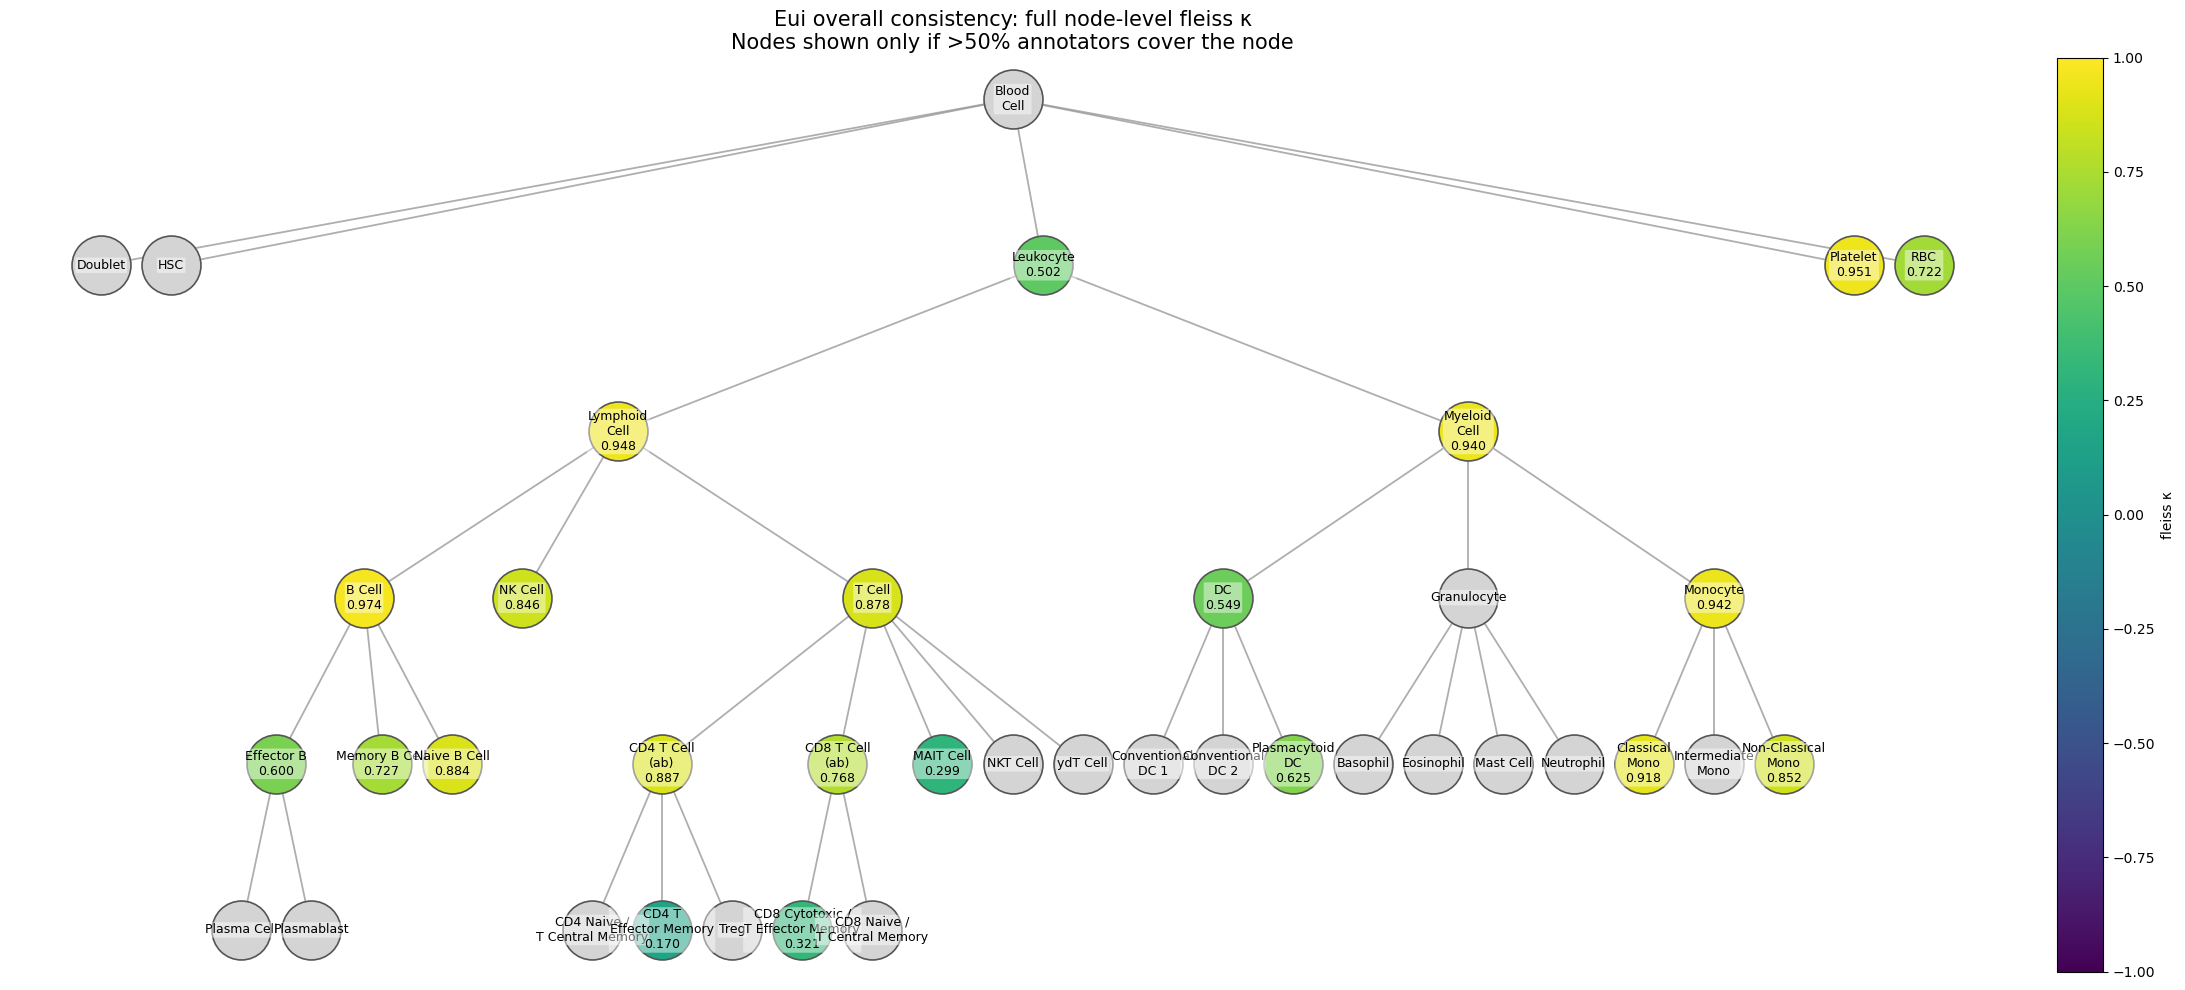

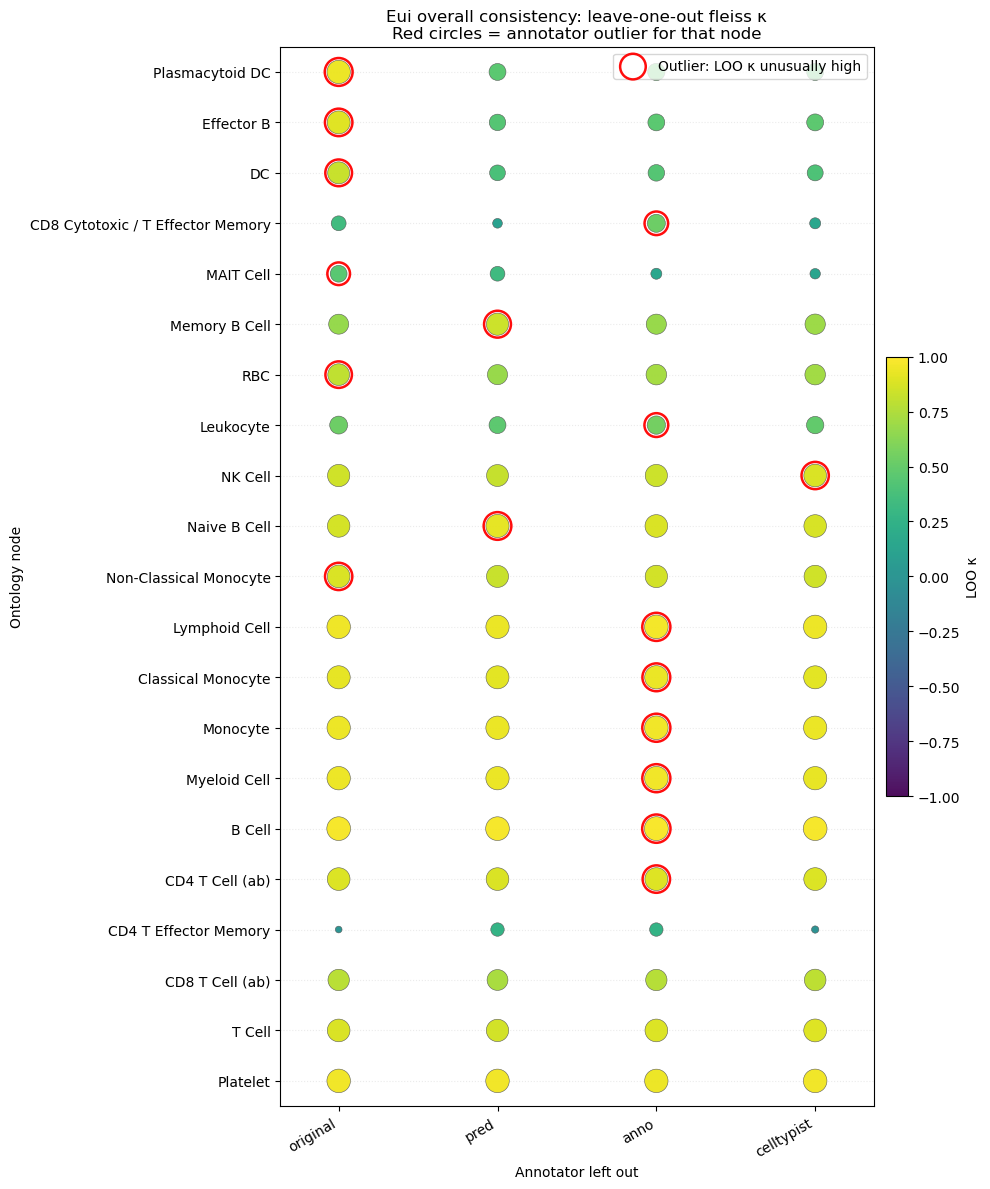


=== Full node-level consistency table ===


,Node,Level,Kappa,Method,use_node,n_annotators,required_pos_annotators,n_pos_annotators,pos_annotators,total_positive_calls,cells_positive_by_any,cells_positive_by_all,Level0,Level1,Level2,Level3,Level4,Level5
0,Doublet,1,NaN,fleiss,False,4,3,0,,0,0,0,Blood Cell,Doublet,NaN,NaN,NaN,NaN
1,HSC,1,NaN,fleiss,False,4,3,2,"pred,celltypist",32,21,0,Blood Cell,HSC,NaN,NaN,NaN,NaN
2,Leukocyte,1,0.502167,fleiss,True,4,3,4,"original,pred,anno,celltypist",158817,40776,37413,Blood Cell,Leukocyte,NaN,NaN,NaN,NaN
3,Platelet,1,0.950996,fleiss,True,4,3,4,"original,pred,anno,celltypist",2943,805,672,Blood Cell,Platelet,NaN,NaN,NaN,NaN
4,RBC,1,0.722348,fleiss,True,4,3,4,"original,pred,anno,celltypist",646,264,96,Blood Cell,RBC,NaN,NaN,NaN,NaN
5,Lymphoid Cell,2,0.947598,fleiss,True,4,3,4,"original,pred,anno,celltypist",104534,26815,24881,Blood Cell,Leukocyte,Lymphoid Cell,NaN,NaN,NaN
6,Myeloid Cell,2,0.940402,fleiss,True,4,3,4,"original,pred,anno,celltypist",53649,14160,12212,Blood Cell,Leukocyte,Myeloid Cell,NaN,NaN,NaN
7,B Cell,3,0.973936,fleiss,True,4,3,4,"original,pred,anno,celltypist",20374,5272,4835,Blood Cell,Leukocyte,Lymphoid Cell,B Cell,NaN,NaN
8,NK Cell,3,0.845931,fleiss,True,4,3,4,"original,pred,anno,celltypist",30637,9397,5820,Blood Cell,Leukocyte,Lymphoid Cell,NK Cell,NaN,NaN
9,T Cell,3,0.877949,fleiss,True,4,3,4,"original,pred,anno,celltypist",53348,15356,11242,Blood Cell,Leukocyte,Lymphoid Cell,T Cell,NaN,NaN



=== Nodes used for κ calculation ===


,Node,Level,Kappa,Method,use_node,n_annotators,required_pos_annotators,n_pos_annotators,pos_annotators,total_positive_calls,cells_positive_by_any,cells_positive_by_all,Level0,Level1,Level2,Level3,Level4,Level5
2,Leukocyte,1,0.502167,fleiss,True,4,3,4,"original,pred,anno,celltypist",158817,40776,37413,Blood Cell,Leukocyte,NaN,NaN,NaN,NaN
3,Platelet,1,0.950996,fleiss,True,4,3,4,"original,pred,anno,celltypist",2943,805,672,Blood Cell,Platelet,NaN,NaN,NaN,NaN
4,RBC,1,0.722348,fleiss,True,4,3,4,"original,pred,anno,celltypist",646,264,96,Blood Cell,RBC,NaN,NaN,NaN,NaN
5,Lymphoid Cell,2,0.947598,fleiss,True,4,3,4,"original,pred,anno,celltypist",104534,26815,24881,Blood Cell,Leukocyte,Lymphoid Cell,NaN,NaN,NaN
6,Myeloid Cell,2,0.940402,fleiss,True,4,3,4,"original,pred,anno,celltypist",53649,14160,12212,Blood Cell,Leukocyte,Myeloid Cell,NaN,NaN,NaN
7,B Cell,3,0.973936,fleiss,True,4,3,4,"original,pred,anno,celltypist",20374,5272,4835,Blood Cell,Leukocyte,Lymphoid Cell,B Cell,NaN,NaN
8,NK Cell,3,0.845931,fleiss,True,4,3,4,"original,pred,anno,celltypist",30637,9397,5820,Blood Cell,Leukocyte,Lymphoid Cell,NK Cell,NaN,NaN
9,T Cell,3,0.877949,fleiss,True,4,3,4,"original,pred,anno,celltypist",53348,15356,11242,Blood Cell,Leukocyte,Lymphoid Cell,T Cell,NaN,NaN
10,DC,3,0.548543,fleiss,True,4,3,3,"pred,anno,celltypist",439,186,0,Blood Cell,Leukocyte,Myeloid Cell,DC,NaN,NaN
12,Monocyte,3,0.942316,fleiss,True,4,3,4,"original,pred,anno,celltypist",53177,14035,12165,Blood Cell,Leukocyte,Myeloid Cell,Monocyte,NaN,NaN



=== LOO outlier summary by annotator ===


,annotator,n_valid_nodes,mean_delta_kappa_LOO_minus_full,median_delta_kappa_LOO_minus_full,pct_nodes_improved_after_leaving_out,n_outlier_nodes,pct_outlier_nodes,mean_z_high,max_z_high,outlier_nodes
0,anno,21,-0.008261,0.003477,0.571429,8,0.380952,0.551749,9.072360,Leukocyte; Lymphoid Cell; Myeloid Cell; B Cell...
1,original,21,0.044368,0.002208,0.619048,6,0.285714,4.332284,38.006564,RBC; DC; Effector B; MAIT Cell; Plasmacytoid D...
2,pred,21,-0.032505,-0.013349,0.238095,2,0.095238,-0.192418,11.837310,Memory B Cell; Naive B Cell
3,celltypist,21,-0.047792,-0.010844,0.238095,1,0.047619,-0.175888,2.828551,NK Cell



=== Node-level LOO outlier table ===


,Node,annotator_left_out,full_kappa,loo_kappa,delta_kappa_LOO_minus_full,z_high,one_sided_p_high,is_outlier
0,Leukocyte,original,0.502167,0.524144,0.021977,0.516240,3.028436e-01,False
1,Leukocyte,pred,0.502167,0.461268,-0.040900,-2.013191,9.779527e-01,False
2,Leukocyte,anno,0.502167,0.550344,0.048177,1.855248,3.178041e-02,True
3,Leukocyte,celltypist,0.502167,0.490499,-0.011668,-0.467886,6.800669e-01,False
4,Platelet,original,0.950996,0.953204,0.002208,0.484920,3.138666e-01,False
5,Platelet,pred,0.950996,0.953423,0.002426,0.538399,2.951509e-01,False
6,Platelet,anno,0.950996,0.943358,-0.007638,-22.230267,1.000000e+00,False
7,Platelet,celltypist,0.950996,0.954086,0.003090,0.711692,2.383277e-01,False
8,RBC,original,0.722348,0.801642,0.079294,5.124574,1.491053e-07,True
9,RBC,pred,0.722348,0.675984,-0.046364,-1.236369,8.918392e-01,False


/tmp/ipykernel_3986076/2131563530.py:491: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


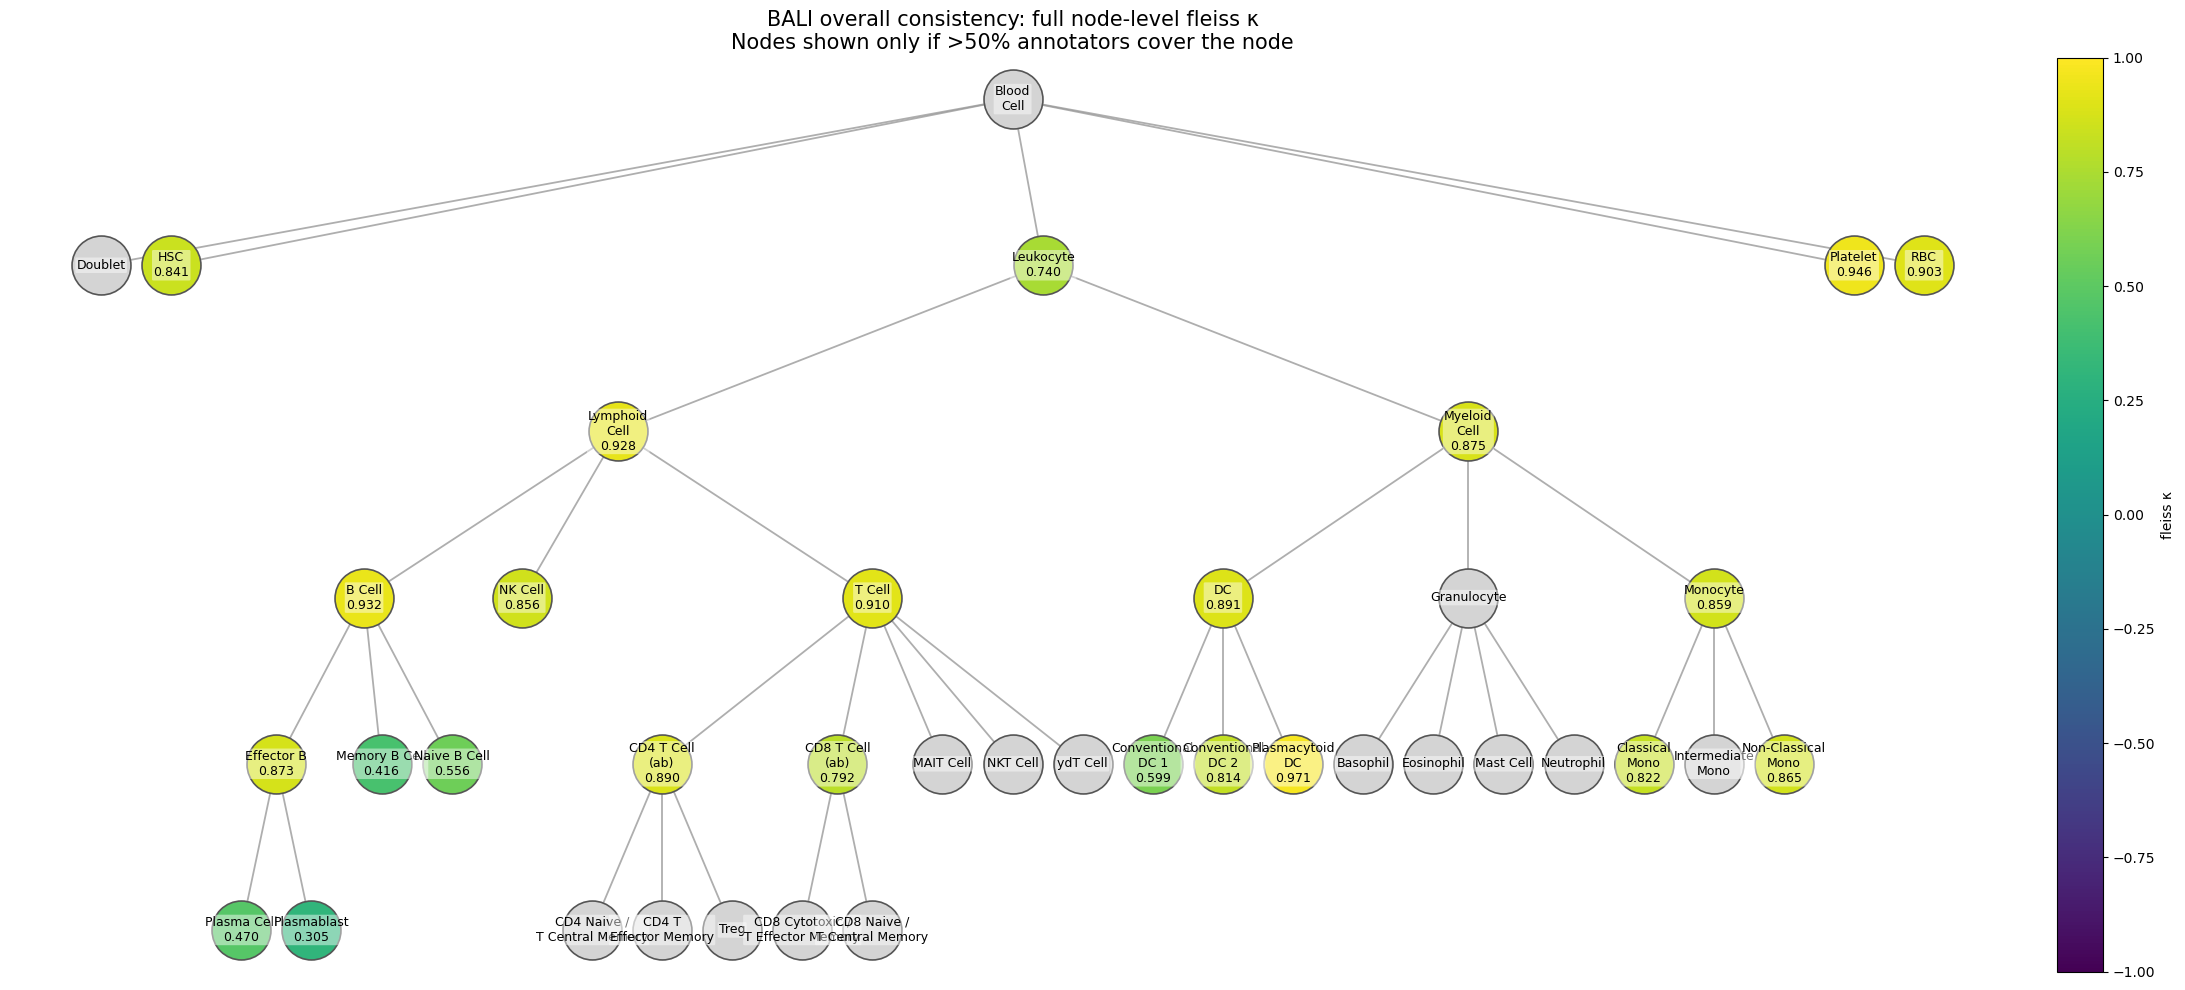

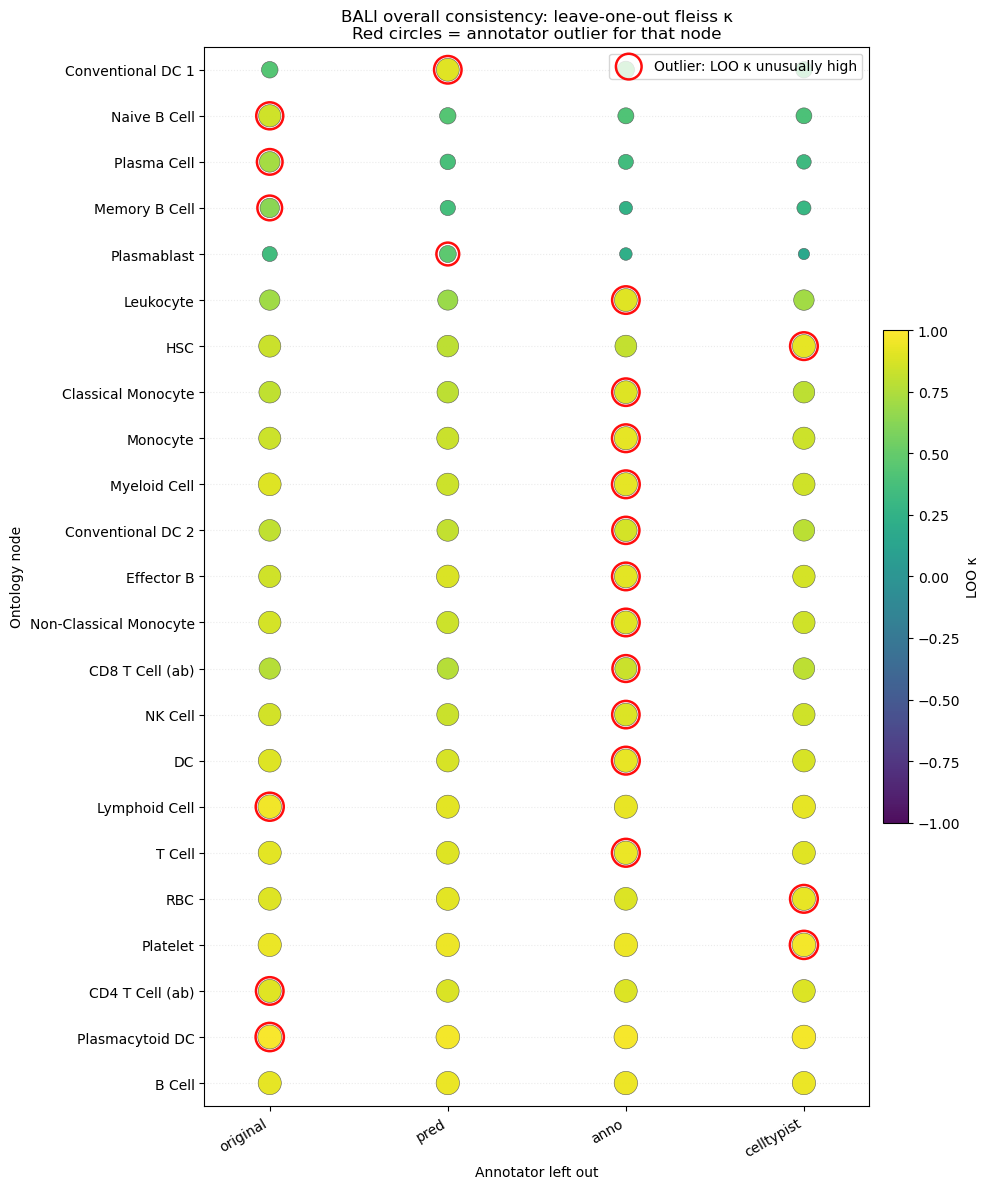


=== Full node-level consistency table ===


,Node,Level,Kappa,Method,use_node,n_annotators,required_pos_annotators,n_pos_annotators,pos_annotators,total_positive_calls,cells_positive_by_any,cells_positive_by_all,Level0,Level1,Level2,Level3,Level4,Level5
0,Doublet,1,NaN,fleiss,False,4,3,0,,0,0,0,Blood Cell,Doublet,NaN,NaN,NaN,NaN
1,HSC,1,0.840632,fleiss,True,4,3,4,"original,pred,anno,celltypist",2349,738,382,Blood Cell,HSC,NaN,NaN,NaN,NaN
2,Leukocyte,1,0.740148,fleiss,True,4,3,4,"original,pred,anno,celltypist",194308,50269,44830,Blood Cell,Leukocyte,NaN,NaN,NaN,NaN
3,Platelet,1,0.946287,fleiss,True,4,3,4,"original,pred,anno,celltypist",15691,4288,3547,Blood Cell,Platelet,NaN,NaN,NaN,NaN
4,RBC,1,0.902705,fleiss,True,4,3,4,"original,pred,anno,celltypist",815,254,180,Blood Cell,RBC,NaN,NaN,NaN,NaN
5,Lymphoid Cell,2,0.928070,fleiss,True,4,3,4,"original,pred,anno,celltypist",117347,30738,27034,Blood Cell,Leukocyte,Lymphoid Cell,NaN,NaN,NaN
6,Myeloid Cell,2,0.875198,fleiss,True,4,3,4,"original,pred,anno,celltypist",76961,22037,16035,Blood Cell,Leukocyte,Myeloid Cell,NaN,NaN,NaN
7,B Cell,3,0.932272,fleiss,True,4,3,4,"original,pred,anno,celltypist",20362,5721,4580,Blood Cell,Leukocyte,Lymphoid Cell,B Cell,NaN,NaN
8,NK Cell,3,0.856229,fleiss,True,4,3,4,"original,pred,anno,celltypist",29738,9136,5705,Blood Cell,Leukocyte,Lymphoid Cell,NK Cell,NaN,NaN
9,T Cell,3,0.910487,fleiss,True,4,3,4,"original,pred,anno,celltypist",66950,18747,14842,Blood Cell,Leukocyte,Lymphoid Cell,T Cell,NaN,NaN



=== Nodes used for κ calculation ===


,Node,Level,Kappa,Method,use_node,n_annotators,required_pos_annotators,n_pos_annotators,pos_annotators,total_positive_calls,cells_positive_by_any,cells_positive_by_all,Level0,Level1,Level2,Level3,Level4,Level5
1,HSC,1,0.840632,fleiss,True,4,3,4,"original,pred,anno,celltypist",2349,738,382,Blood Cell,HSC,NaN,NaN,NaN,NaN
2,Leukocyte,1,0.740148,fleiss,True,4,3,4,"original,pred,anno,celltypist",194308,50269,44830,Blood Cell,Leukocyte,NaN,NaN,NaN,NaN
3,Platelet,1,0.946287,fleiss,True,4,3,4,"original,pred,anno,celltypist",15691,4288,3547,Blood Cell,Platelet,NaN,NaN,NaN,NaN
4,RBC,1,0.902705,fleiss,True,4,3,4,"original,pred,anno,celltypist",815,254,180,Blood Cell,RBC,NaN,NaN,NaN,NaN
5,Lymphoid Cell,2,0.928070,fleiss,True,4,3,4,"original,pred,anno,celltypist",117347,30738,27034,Blood Cell,Leukocyte,Lymphoid Cell,NaN,NaN,NaN
6,Myeloid Cell,2,0.875198,fleiss,True,4,3,4,"original,pred,anno,celltypist",76961,22037,16035,Blood Cell,Leukocyte,Myeloid Cell,NaN,NaN,NaN
7,B Cell,3,0.932272,fleiss,True,4,3,4,"original,pred,anno,celltypist",20362,5721,4580,Blood Cell,Leukocyte,Lymphoid Cell,B Cell,NaN,NaN
8,NK Cell,3,0.856229,fleiss,True,4,3,4,"original,pred,anno,celltypist",29738,9136,5705,Blood Cell,Leukocyte,Lymphoid Cell,NK Cell,NaN,NaN
9,T Cell,3,0.910487,fleiss,True,4,3,4,"original,pred,anno,celltypist",66950,18747,14842,Blood Cell,Leukocyte,Lymphoid Cell,T Cell,NaN,NaN
10,DC,3,0.890926,fleiss,True,4,3,4,"original,pred,anno,celltypist",23351,6901,4788,Blood Cell,Leukocyte,Myeloid Cell,DC,NaN,NaN



=== LOO outlier summary by annotator ===


,annotator,n_valid_nodes,mean_delta_kappa_LOO_minus_full,median_delta_kappa_LOO_minus_full,pct_nodes_improved_after_leaving_out,n_outlier_nodes,pct_outlier_nodes,mean_z_high,max_z_high,outlier_nodes
0,anno,23,-0.004256,0.006862,0.565217,11,0.478261,6.598017,66.371139,Leukocyte; Myeloid Cell; NK Cell; T Cell; DC; ...
1,original,23,0.022363,-0.001745,0.434783,6,0.260870,2.092321,26.404886,Lymphoid Cell; Memory B Cell; Naive B Cell; CD...
2,celltypist,23,-0.036039,-0.015320,0.217391,3,0.130435,-0.017510,5.243786,HSC; Platelet; RBC
3,pred,23,-0.005457,-0.017532,0.217391,2,0.086957,0.199107,16.523438,Conventional DC 1; Plasmablast



=== Node-level LOO outlier table ===


,Node,annotator_left_out,full_kappa,loo_kappa,delta_kappa_LOO_minus_full,z_high,one_sided_p_high,is_outlier
0,HSC,original,0.840632,0.833110,-0.007522,-0.106463,5.423926e-01,False
1,HSC,pred,0.840632,0.794466,-0.046166,-1.072728,8.583035e-01,False
2,HSC,anno,0.840632,0.811103,-0.029529,-0.591717,7.229801e-01,False
3,HSC,celltypist,0.840632,0.914539,0.073907,5.243786,7.865749e-08,True
4,Leukocyte,original,0.740148,0.701187,-0.038961,-0.523381,6.996455e-01,False
5,Leukocyte,pred,0.740148,0.683280,-0.056868,-0.762516,7.771240e-01,False
6,Leukocyte,anno,0.740148,0.898709,0.158561,16.281964,6.627305e-60,True
7,Leukocyte,celltypist,0.740148,0.707037,-0.033111,-0.451896,6.743281e-01,False
8,Platelet,original,0.946287,0.933484,-0.012803,-1.461630,9.280787e-01,False
9,Platelet,pred,0.946287,0.942931,-0.003356,-0.287574,6.131637e-01,False


In [7]:
# Eui example
overall_eui = run_overall_consistency_and_loo_outlier_analysis(
    eui_onto_annotator_table,
    columns=None,   # use all annotation columns
    method="fleiss",
    include_root=False,
    coverage_fraction=0.5,  # >50%
    min_pos_per_annotator=1,
    z_threshold=1.5,
    require_delta_positive=True,
    title_prefix="Eui overall consistency",
    max_nodes_dotplot=60,
)

eui_consistency_table = overall_eui["consistency_table"]
eui_loo_summary = overall_eui["loo_results"]["outlier_summary"]
eui_node_outlier_table = overall_eui["loo_results"]["node_outlier_table"]


# BALI example
overall_bali = run_overall_consistency_and_loo_outlier_analysis(
    bali_onto_annotator_table,
    columns=None,
    method="fleiss",
    include_root=False,
    coverage_fraction=0.5,
    min_pos_per_annotator=1,
    z_threshold=1.5,
    require_delta_positive=True,
    title_prefix="BALI overall consistency",
    max_nodes_dotplot=60,
)

bali_consistency_table = overall_bali["consistency_table"]
bali_loo_summary = overall_bali["loo_results"]["outlier_summary"]
bali_node_outlier_table = overall_bali["loo_results"]["node_outlier_table"]

In [8]:
# =========================================================
# Individual annotator report
# A vs B and A vs C separately
# =========================================================

def build_pairwise_target_reference_table(
    annotator_table,
    target_col,
    reference_col,
    include_root=False,
    min_pos_per_side=1,
):
    """
    Compute node-level Cohen κ for:
        target annotator A vs reference annotator B.

    This is binary node/subtree membership for each ontology node.
    """
    if target_col not in annotator_table.columns:
        raise ValueError(f"{target_col} not found in annotator_table.")

    if reference_col not in annotator_table.columns:
        raise ValueError(f"{reference_col} not found in annotator_table.")

    rows = []

    for node in nodes:
        if node == ROOT and not include_root:
            continue

        sub_nodes = descendants[node]

        target_binary = annotator_table[target_col].isin(sub_nodes).to_numpy()
        ref_binary = annotator_table[reference_col].isin(sub_nodes).to_numpy()

        target_pos = int(target_binary.sum())
        ref_pos = int(ref_binary.sum())

        if target_pos < min_pos_per_side or ref_pos < min_pos_per_side:
            kappa = np.nan
        else:
            kappa = cohens_kappa_binary(target_binary, ref_binary)

        both_pos = int((target_binary & ref_binary).sum())
        target_only = int((target_binary & ~ref_binary).sum())
        ref_only = int((~target_binary & ref_binary).sum())
        either_pos = int((target_binary | ref_binary).sum())

        if either_pos > 0:
            jaccard = both_pos / either_pos
        else:
            jaccard = np.nan

        if ref_pos > 0:
            target_ref_ratio = target_pos / ref_pos
        else:
            target_ref_ratio = np.nan

        path = path_to_root(node)

        row = {
            "Node": node,
            "Level": level[node],
            "target_col": target_col,
            "reference_col": reference_col,
            "Kappa": kappa,
            "target_positive_cells": target_pos,
            "reference_positive_cells": ref_pos,
            "both_positive_cells": both_pos,
            "target_only_cells": target_only,
            "reference_only_cells": ref_only,
            "either_positive_cells": either_pos,
            "jaccard_positive_set": jaccard,
            "target_to_reference_positive_ratio": target_ref_ratio,
        }

        for L in range(MAX_LEVEL + 1):
            row[f"Level{L}"] = path[L] if L < len(path) else np.nan

        rows.append(row)

    out = pd.DataFrame(rows)

    out = out.sort_values(
        ["Level"] + [f"Level{L}" for L in range(MAX_LEVEL + 1)]
    ).reset_index(drop=True)

    return out


def make_pairwise_tree_table(pairwise_table):
    """
    Convert pairwise table into the format expected by plot_ontology_kappa_tree().
    """
    out = pairwise_table.copy()
    out["use_node"] = out["Kappa"].notna()
    return out


def summarize_pairwise_target_reference(pairwise_table):
    """
    Summary for one A vs reference comparison.
    """
    valid = pairwise_table[pairwise_table["Kappa"].notna()].copy()

    if valid.shape[0] == 0:
        return pd.DataFrame([{
            "target_col": pairwise_table["target_col"].iloc[0],
            "reference_col": pairwise_table["reference_col"].iloc[0],
            "n_valid_nodes": 0,
            "mean_kappa": np.nan,
            "median_kappa": np.nan,
            "n_low_kappa_nodes_lt_0.2": 0,
            "n_negative_kappa_nodes": 0,
            "major_message": "No valid nodes for comparison.",
        }])

    low_nodes = valid[valid["Kappa"] < 0.2]
    neg_nodes = valid[valid["Kappa"] < 0]

    mean_k = valid["Kappa"].mean()
    median_k = valid["Kappa"].median()

    if mean_k >= 0.6:
        msg = "Overall agreement is strong across covered ontology nodes."
    elif mean_k >= 0.3:
        msg = "Overall agreement is moderate; several nodes may need review."
    else:
        msg = "Overall agreement is weak; annotation definitions or mapping likely need review."

    return pd.DataFrame([{
        "target_col": pairwise_table["target_col"].iloc[0],
        "reference_col": pairwise_table["reference_col"].iloc[0],
        "n_valid_nodes": int(valid.shape[0]),
        "mean_kappa": float(mean_k),
        "median_kappa": float(median_k),
        "min_kappa": float(valid["Kappa"].min()),
        "max_kappa": float(valid["Kappa"].max()),
        "n_low_kappa_nodes_lt_0.2": int(low_nodes.shape[0]),
        "n_negative_kappa_nodes": int(neg_nodes.shape[0]),
        "major_message": msg,
    }])


def make_actionable_node_feedback(
    pairwise_table,
    top_n=10,
    min_either_positive_cells=10,
):
    """
    Create an informative table for annotation groups.

    This table highlights:
        1. low κ nodes
        2. where target over-calls compared with reference
        3. where target under-calls compared with reference
    """
    df = pairwise_table.copy()

    df = df[
        (df["either_positive_cells"] >= min_either_positive_cells)
        & (df["Kappa"].notna())
    ].copy()

    if df.shape[0] == 0:
        return pd.DataFrame()

    # Avoid division artifacts
    df["abs_positive_difference"] = (
        df["target_positive_cells"] - df["reference_positive_cells"]
    ).abs()

    df["direction"] = np.where(
        df["target_positive_cells"] > df["reference_positive_cells"],
        "target_overcalls_vs_reference",
        np.where(
            df["target_positive_cells"] < df["reference_positive_cells"],
            "target_undercalls_vs_reference",
            "similar_positive_count",
        )
    )

    df["review_priority_score"] = (
        (1 - df["Kappa"].clip(lower=-1, upper=1)) * 1.0
        + np.log1p(df["abs_positive_difference"]) * 0.15
        + np.log1p(df["either_positive_cells"]) * 0.05
    )

    out = df.sort_values(
        ["review_priority_score", "either_positive_cells"],
        ascending=[False, False],
    ).head(top_n)

    keep_cols = [
        "Node",
        "Level",
        "Kappa",
        "target_positive_cells",
        "reference_positive_cells",
        "both_positive_cells",
        "target_only_cells",
        "reference_only_cells",
        "jaccard_positive_set",
        "target_to_reference_positive_ratio",
        "direction",
        "review_priority_score",
    ]

    return out[keep_cols].reset_index(drop=True)


def run_individual_annotator_report(
    annotator_table,
    target_col,
    reference_cols,
    include_root=False,
    min_pos_per_side=1,
    min_either_positive_cells_for_feedback=10,
    top_n_feedback=10,
    title_prefix=None,
):
    """
    Main Part 2 wrapper.

    Example:
        target_col = "celltypist"
        reference_cols = ["original", "pred"]

    It draws:
        1. target vs reference 1 ontology tree
        2. target vs reference 2 ontology tree

    It returns:
        - pairwise node-level κ tables
        - summary tables
        - actionable feedback tables
    """
    if isinstance(reference_cols, str):
        reference_cols = [reference_cols]

    reference_cols = list(reference_cols)

    if title_prefix is None:
        title_prefix = f"{target_col} annotation report"

    pairwise_tables = {}
    summary_tables = {}
    feedback_tables = {}

    for ref_col in reference_cols:
        pair_tbl = build_pairwise_target_reference_table(
            annotator_table,
            target_col=target_col,
            reference_col=ref_col,
            include_root=include_root,
            min_pos_per_side=min_pos_per_side,
        )

        pairwise_tables[ref_col] = pair_tbl

        tree_tbl = make_pairwise_tree_table(pair_tbl)

        plot_ontology_kappa_tree(
            tree_tbl,
            score_col="Kappa",
            title=f"{title_prefix}: {target_col} vs {ref_col}",
            metric_label="Cohen κ",
            vmin=-1,
            vmax=1,
            only_show_used_scores=True,
        )

        summary_tbl = summarize_pairwise_target_reference(pair_tbl)
        feedback_tbl = make_actionable_node_feedback(
            pair_tbl,
            top_n=top_n_feedback,
            min_either_positive_cells=min_either_positive_cells_for_feedback,
        )

        summary_tables[ref_col] = summary_tbl
        feedback_tables[ref_col] = feedback_tbl

        print(f"\n=== Summary: {target_col} vs {ref_col} ===")
        display(summary_tbl)

        print(f"\n=== Node-level κ table head: {target_col} vs {ref_col} ===")
        display(pair_tbl.head(20))

        print(f"\n=== Actionable feedback nodes: {target_col} vs {ref_col} ===")
        display(feedback_tbl)

    combined_summary = pd.concat(
        list(summary_tables.values()),
        axis=0,
        ignore_index=True,
    )

    combined_feedback = []
    for ref_col, tbl in feedback_tables.items():
        if tbl is not None and tbl.shape[0] > 0:
            tmp = tbl.copy()
            tmp.insert(0, "reference_col", ref_col)
            tmp.insert(0, "target_col", target_col)
            combined_feedback.append(tmp)

    if len(combined_feedback) > 0:
        combined_feedback = pd.concat(combined_feedback, axis=0, ignore_index=True)
    else:
        combined_feedback = pd.DataFrame()

    print("\n=== Combined summary across references ===")
    display(combined_summary)

    print("\n=== Combined actionable feedback ===")
    display(combined_feedback)

    return {
        "pairwise_tables": pairwise_tables,
        "summary_tables": summary_tables,
        "feedback_tables": feedback_tables,
        "combined_summary": combined_summary,
        "combined_feedback": combined_feedback,
    }

/tmp/ipykernel_3986076/2131563530.py:491: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


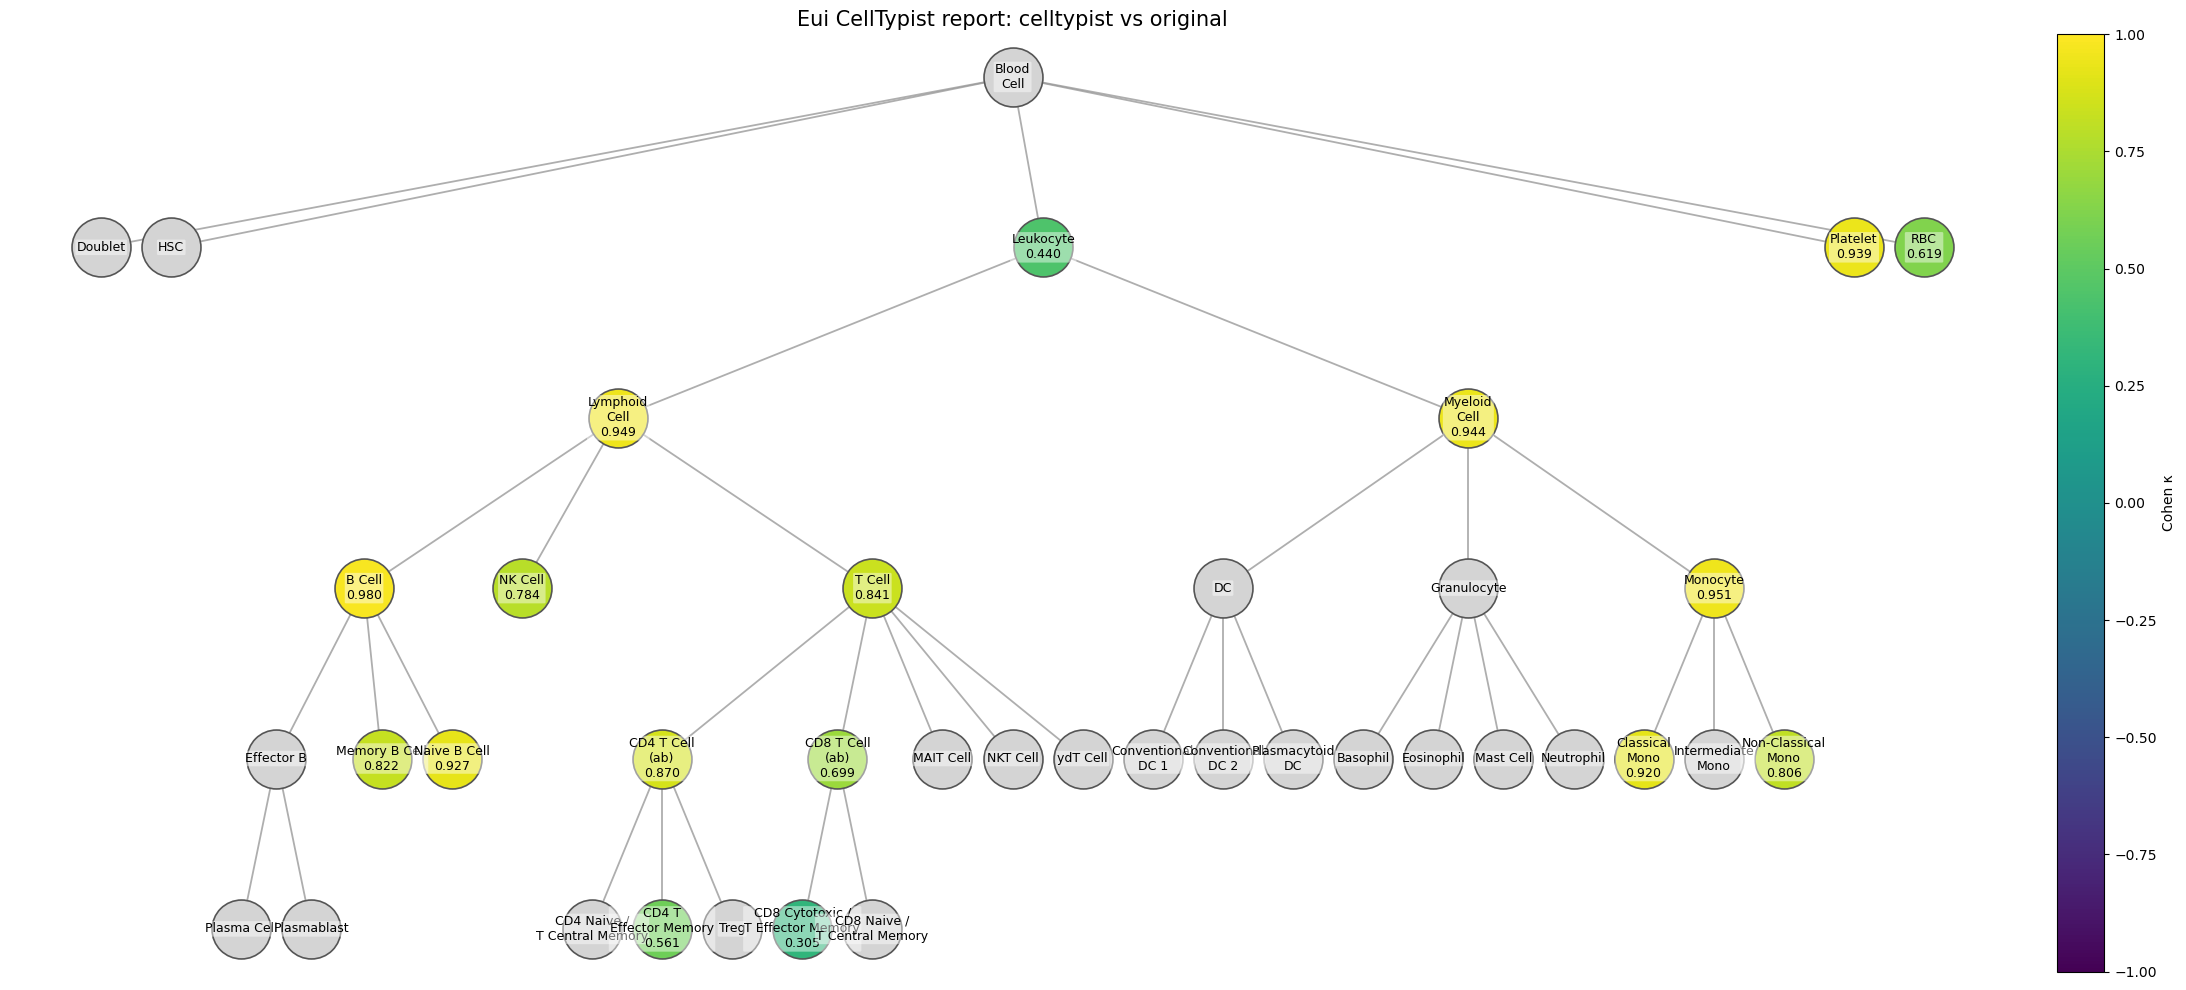


=== Summary: celltypist vs original ===


,target_col,reference_col,n_valid_nodes,mean_kappa,median_kappa,min_kappa,max_kappa,n_low_kappa_nodes_lt_0.2,n_negative_kappa_nodes,major_message
0,celltypist,original,17,0.785607,0.840729,0.305383,0.97984,0,0,Overall agreement is strong across covered ont...



=== Node-level κ table head: celltypist vs original ===


,Node,Level,target_col,reference_col,Kappa,target_positive_cells,reference_positive_cells,both_positive_cells,target_only_cells,reference_only_cells,either_positive_cells,jaccard_positive_set,target_to_reference_positive_ratio,Level0,Level1,Level2,Level3,Level4,Level5
0,Doublet,1,celltypist,original,NaN,0,0,0,0,0,0,NaN,NaN,Blood Cell,Doublet,NaN,NaN,NaN,NaN
1,HSC,1,celltypist,original,NaN,11,0,0,11,0,11,0.000000,NaN,Blood Cell,HSC,NaN,NaN,NaN,NaN
2,Leukocyte,1,celltypist,original,0.439940,40757,38842,38826,1931,16,40773,0.952248,1.049302,Blood Cell,Leukocyte,NaN,NaN,NaN,NaN
3,Platelet,1,celltypist,original,0.938895,703,746,681,22,65,768,0.886719,0.942359,Blood Cell,Platelet,NaN,NaN,NaN,NaN
4,RBC,1,celltypist,original,0.618701,113,216,102,11,114,227,0.449339,0.523148,Blood Cell,RBC,NaN,NaN,NaN,NaN
5,Lymphoid Cell,2,celltypist,original,0.948772,26777,25844,25815,962,29,26806,0.963031,1.036101,Blood Cell,Leukocyte,Lymphoid Cell,NaN,NaN,NaN
6,Myeloid Cell,2,celltypist,original,0.944080,13980,12998,12979,1001,19,13999,0.927138,1.075550,Blood Cell,Leukocyte,Myeloid Cell,NaN,NaN,NaN
7,B Cell,3,celltypist,original,0.979840,5215,5089,5061,154,28,5243,0.965287,1.024759,Blood Cell,Leukocyte,Lymphoid Cell,B Cell,NaN,NaN
8,NK Cell,3,celltypist,original,0.783959,6764,8367,6225,539,2142,8906,0.698967,0.808414,Blood Cell,Leukocyte,Lymphoid Cell,NK Cell,NaN,NaN
9,T Cell,3,celltypist,original,0.840729,14798,12388,12130,2668,258,15056,0.805659,1.194543,Blood Cell,Leukocyte,Lymphoid Cell,T Cell,NaN,NaN



=== Actionable feedback nodes: celltypist vs original ===


,Node,Level,Kappa,target_positive_cells,reference_positive_cells,both_positive_cells,target_only_cells,reference_only_cells,jaccard_positive_set,target_to_reference_positive_ratio,direction,review_priority_score
0,CD8 Cytotoxic / T Effector Memory,5,0.305383,9120,2972,2299,6821,673,0.234760,3.068641,target_overcalls_vs_reference,2.462700
1,Leukocyte,1,0.439940,40757,38842,38826,1931,16,0.952248,1.049302,target_overcalls_vs_reference,2.224549
2,CD4 T Effector Memory,5,0.561303,1527,3378,1431,96,1947,0.411917,0.452043,target_undercalls_vs_reference,1.974968
3,CD8 T Cell (ab),4,0.698640,9493,7022,6252,3241,770,0.609179,1.351894,target_overcalls_vs_reference,1.935097
4,T Cell,3,0.840729,14798,12388,12130,2668,258,0.805659,1.194543,target_overcalls_vs_reference,1.808421
5,NK Cell,3,0.783959,6764,8367,6225,539,2142,0.698967,0.808414,target_undercalls_vs_reference,1.777809
6,Lymphoid Cell,2,0.948772,26777,25844,25815,962,29,0.963031,1.036101,target_overcalls_vs_reference,1.586970
7,Myeloid Cell,2,0.944080,13980,12998,12979,1001,19,0.927138,1.075550,target_overcalls_vs_reference,1.566852
8,Monocyte,3,0.950727,13777,12998,12940,837,58,0.935309,1.059932,target_overcalls_vs_reference,1.524918
9,CD4 T Cell (ab),4,0.869818,4829,5366,4515,314,851,0.794894,0.899925,target_undercalls_vs_reference,1.505605


/tmp/ipykernel_3986076/2131563530.py:491: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


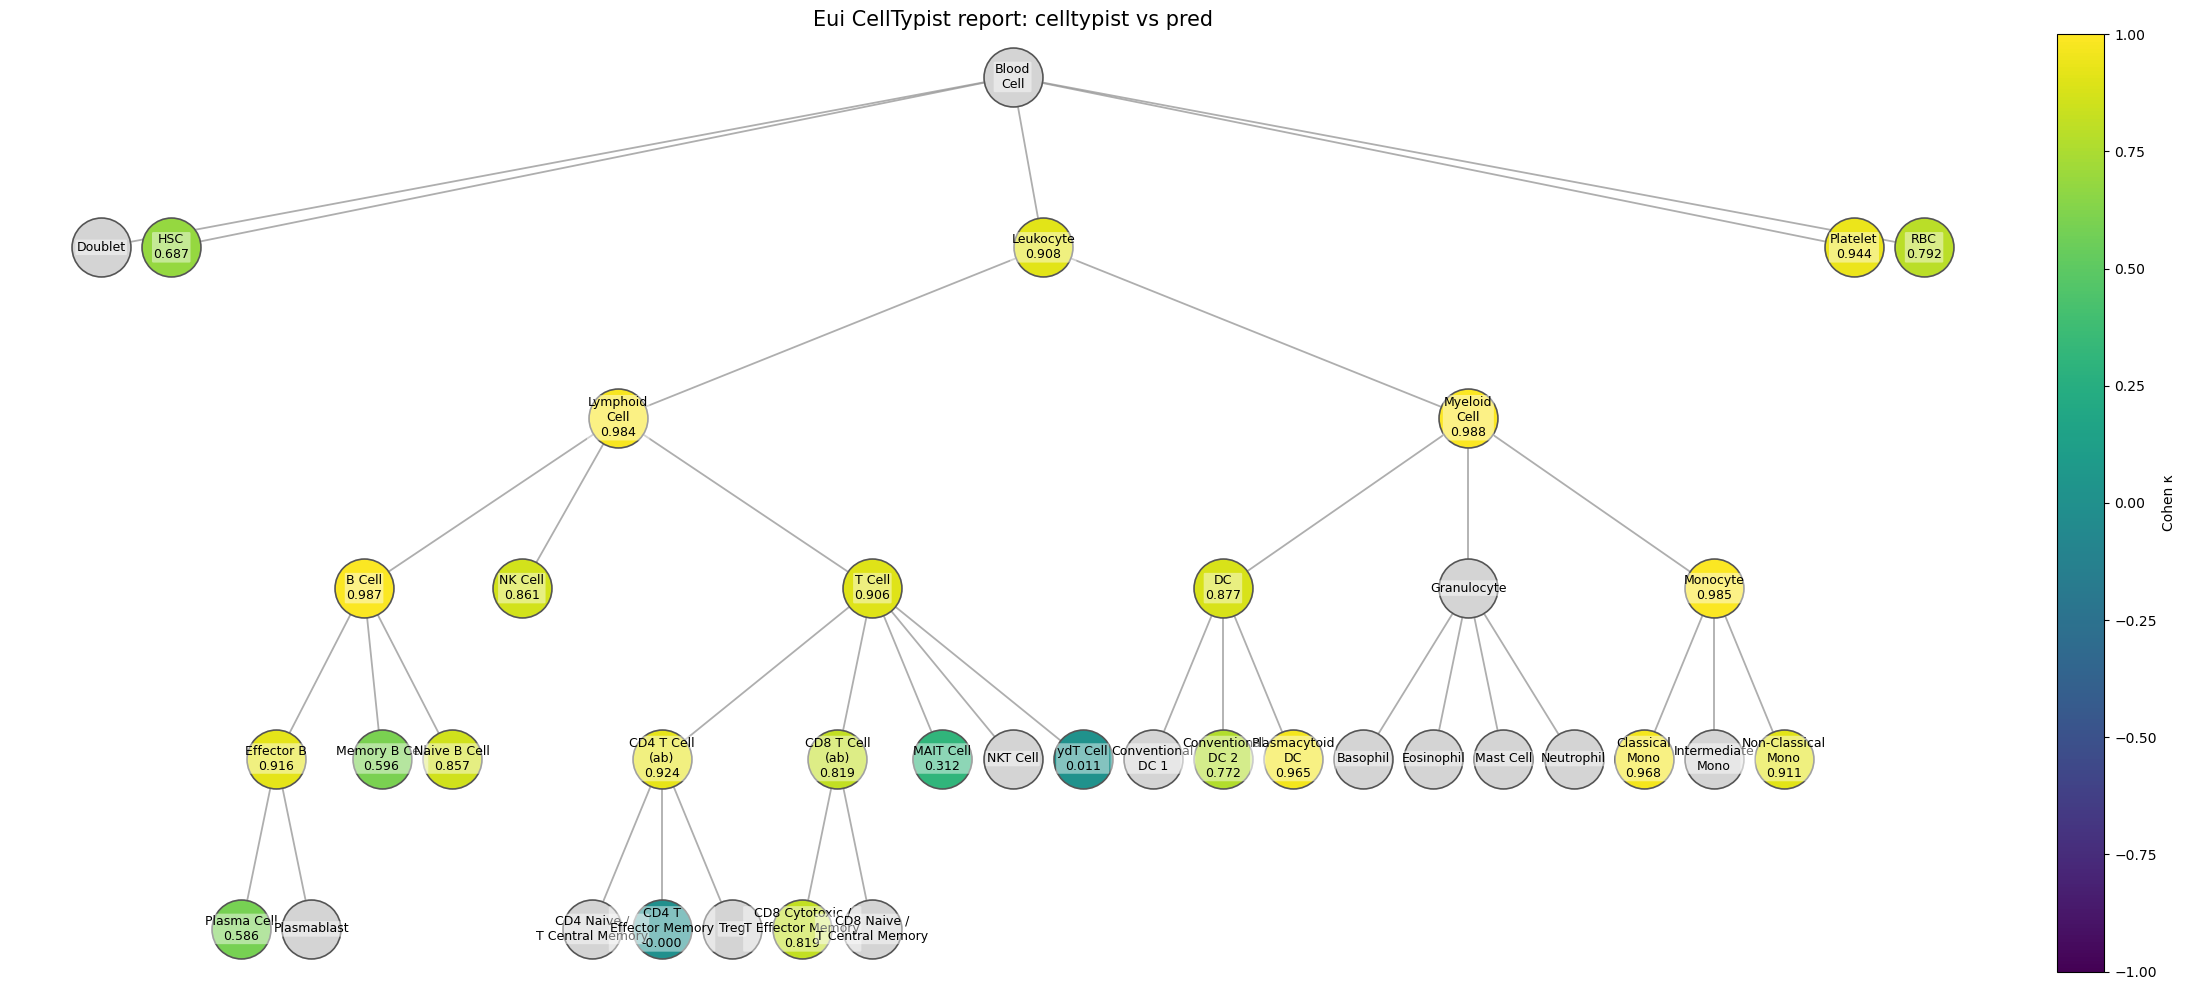


=== Summary: celltypist vs pred ===


,target_col,reference_col,n_valid_nodes,mean_kappa,median_kappa,min_kappa,max_kappa,n_low_kappa_nodes_lt_0.2,n_negative_kappa_nodes,major_message
0,celltypist,pred,25,0.775037,0.876965,-0.00024,0.988285,2,1,Overall agreement is strong across covered ont...



=== Node-level κ table head: celltypist vs pred ===


,Node,Level,target_col,reference_col,Kappa,target_positive_cells,reference_positive_cells,both_positive_cells,target_only_cells,reference_only_cells,either_positive_cells,jaccard_positive_set,target_to_reference_positive_ratio,Level0,Level1,Level2,Level3,Level4,Level5
0,Doublet,1,celltypist,pred,NaN,0,0,0,0,0,0,NaN,NaN,Blood Cell,Doublet,NaN,NaN,NaN,NaN
1,HSC,1,celltypist,pred,0.687391,11,21,11,0,10,21,0.523810,0.523810,Blood Cell,HSC,NaN,NaN,NaN,NaN
2,Leukocyte,1,celltypist,pred,0.908202,40757,40614,40604,153,10,40767,0.996002,1.003521,Blood Cell,Leukocyte,NaN,NaN,NaN,NaN
3,Platelet,1,celltypist,pred,0.944392,703,780,701,2,79,782,0.896419,0.901282,Blood Cell,Platelet,NaN,NaN,NaN,NaN
4,RBC,1,celltypist,pred,0.792301,113,172,113,0,59,172,0.656977,0.656977,Blood Cell,RBC,NaN,NaN,NaN,NaN
5,Lymphoid Cell,2,celltypist,pred,0.983558,26777,26494,26478,299,16,26793,0.988243,1.010682,Blood Cell,Leukocyte,Lymphoid Cell,NaN,NaN,NaN
6,Myeloid Cell,2,celltypist,pred,0.988285,13980,14120,13941,39,179,14159,0.984603,0.990085,Blood Cell,Leukocyte,Myeloid Cell,NaN,NaN,NaN
7,B Cell,3,celltypist,pred,0.986922,5215,5184,5140,75,44,5259,0.977372,1.005980,Blood Cell,Leukocyte,Lymphoid Cell,B Cell,NaN,NaN
8,NK Cell,3,celltypist,pred,0.861121,6764,7690,6397,367,1293,8057,0.793968,0.879584,Blood Cell,Leukocyte,Lymphoid Cell,NK Cell,NaN,NaN
9,T Cell,3,celltypist,pred,0.906016,14798,13620,13329,1469,291,15089,0.883359,1.086490,Blood Cell,Leukocyte,Lymphoid Cell,T Cell,NaN,NaN



=== Actionable feedback nodes: celltypist vs pred ===


...


=== Combined summary across references ===


,target_col,reference_col,n_valid_nodes,mean_kappa,median_kappa,min_kappa,max_kappa,n_low_kappa_nodes_lt_0.2,n_negative_kappa_nodes,major_message
0,celltypist,original,17,0.785607,0.840729,0.305383,0.979840,0,0,Overall agreement is strong across covered ont...
1,celltypist,pred,25,0.775037,0.876965,-0.000240,0.988285,2,1,Overall agreement is strong across covered ont...



=== Combined actionable feedback ===


,target_col,reference_col,Node,Level,Kappa,target_positive_cells,reference_positive_cells,both_positive_cells,target_only_cells,reference_only_cells,jaccard_positive_set,target_to_reference_positive_ratio,direction,review_priority_score
0,celltypist,original,CD8 Cytotoxic / T Effector Memory,5,0.305383,9120,2972,2299,6821,673,0.234760,3.068641,target_overcalls_vs_reference,2.462700
1,celltypist,original,Leukocyte,1,0.439940,40757,38842,38826,1931,16,0.952248,1.049302,target_overcalls_vs_reference,2.224549
2,celltypist,original,CD4 T Effector Memory,5,0.561303,1527,3378,1431,96,1947,0.411917,0.452043,target_undercalls_vs_reference,1.974968
3,celltypist,original,CD8 T Cell (ab),4,0.698640,9493,7022,6252,3241,770,0.609179,1.351894,target_overcalls_vs_reference,1.935097
4,celltypist,original,T Cell,3,0.840729,14798,12388,12130,2668,258,0.805659,1.194543,target_overcalls_vs_reference,1.808421
5,celltypist,original,NK Cell,3,0.783959,6764,8367,6225,539,2142,0.698967,0.808414,target_undercalls_vs_reference,1.777809
6,celltypist,original,Lymphoid Cell,2,0.948772,26777,25844,25815,962,29,0.963031,1.036101,target_overcalls_vs_reference,1.586970
7,celltypist,original,Myeloid Cell,2,0.944080,13980,12998,12979,1001,19,0.927138,1.075550,target_overcalls_vs_reference,1.566852
8,celltypist,original,Monocyte,3,0.950727,13777,12998,12940,837,58,0.935309,1.059932,target_overcalls_vs_reference,1.524918
9,celltypist,original,CD4 T Cell (ab),4,0.869818,4829,5366,4515,314,851,0.794894,0.899925,target_undercalls_vs_reference,1.505605


/tmp/ipykernel_3986076/2131563530.py:491: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


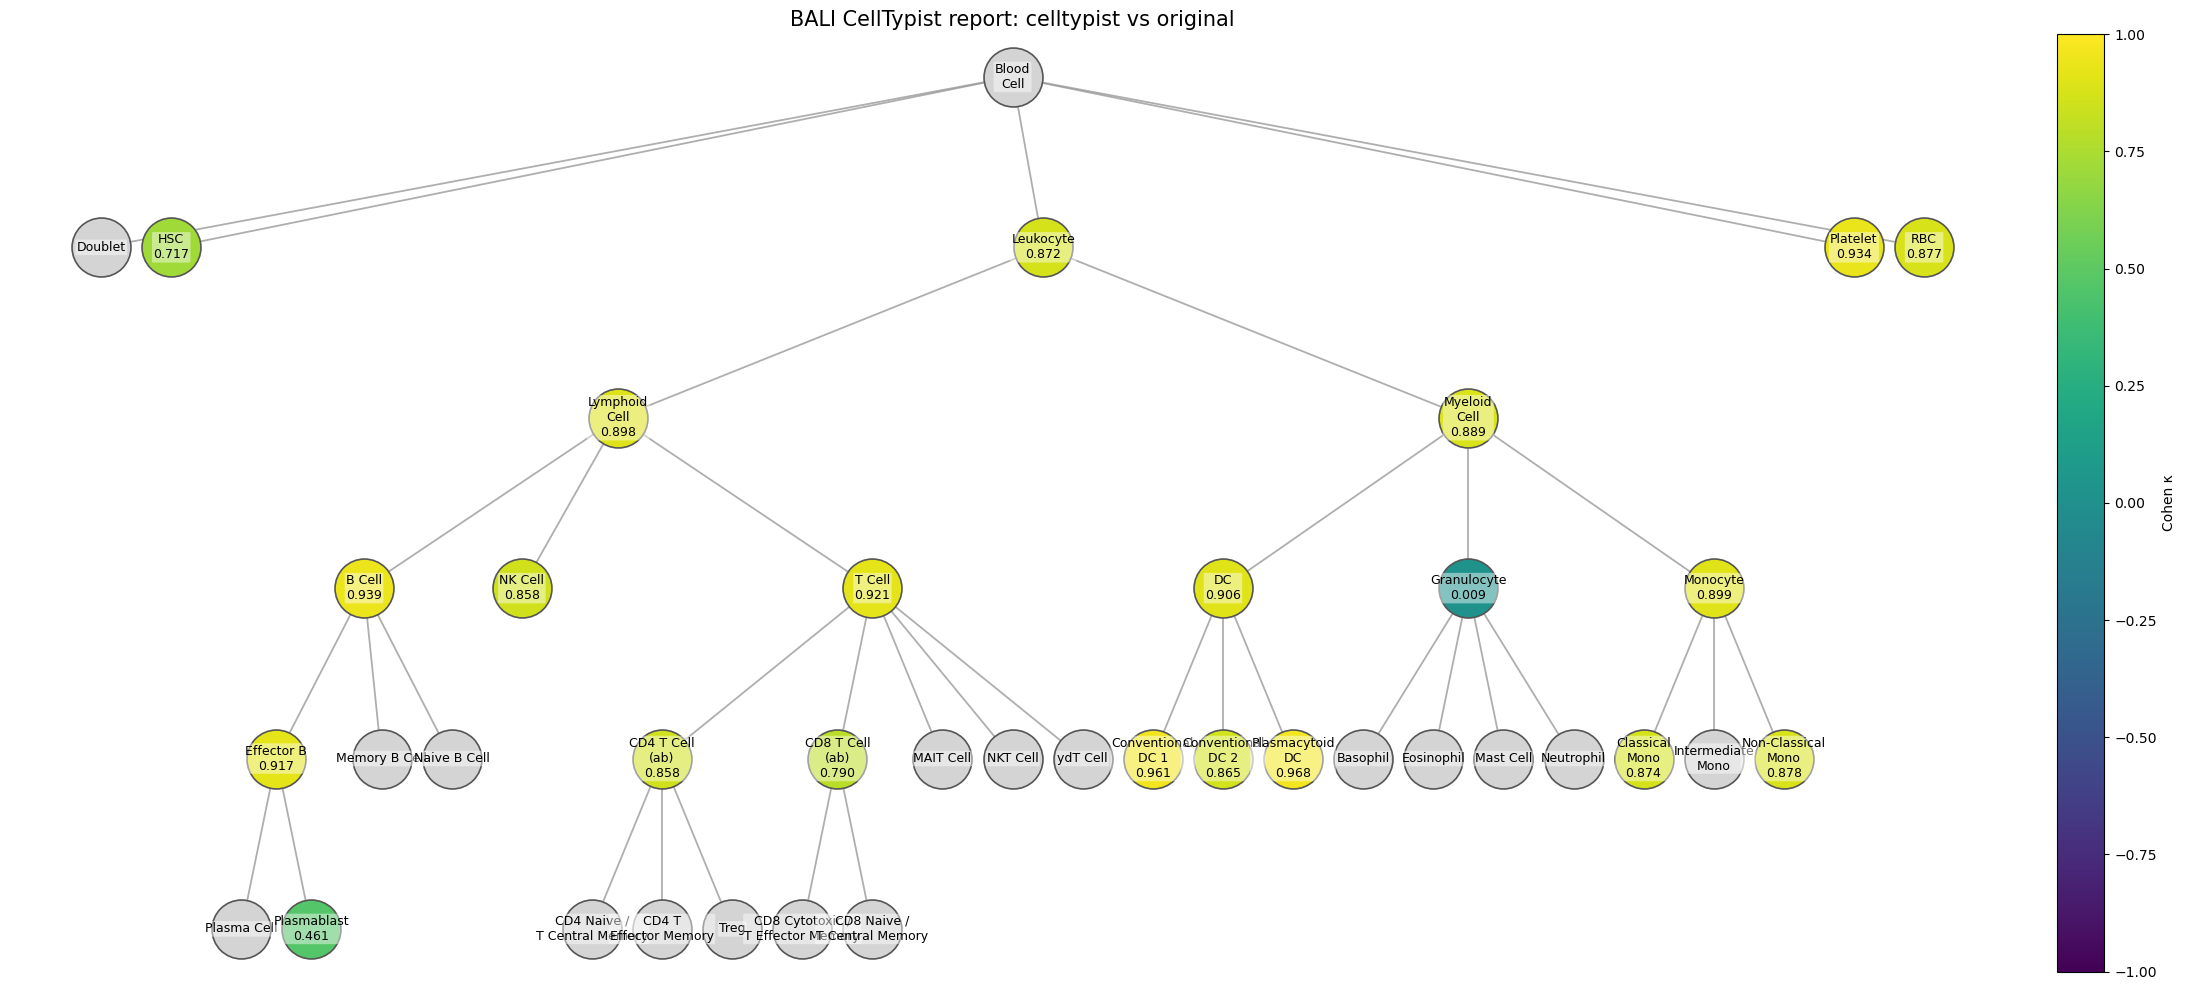


=== Summary: celltypist vs original ===


,target_col,reference_col,n_valid_nodes,mean_kappa,median_kappa,min_kappa,max_kappa,n_low_kappa_nodes_lt_0.2,n_negative_kappa_nodes,major_message
0,celltypist,original,21,0.823468,0.878309,0.009074,0.967605,1,0,Overall agreement is strong across covered ont...



=== Node-level κ table head: celltypist vs original ===


,Node,Level,target_col,reference_col,Kappa,target_positive_cells,reference_positive_cells,both_positive_cells,target_only_cells,reference_only_cells,either_positive_cells,jaccard_positive_set,target_to_reference_positive_ratio,Level0,Level1,Level2,Level3,Level4,Level5
0,Doublet,1,celltypist,original,NaN,0,0,0,0,0,0,NaN,NaN,Blood Cell,Doublet,NaN,NaN,NaN,NaN
1,HSC,1,celltypist,original,0.717166,407,721,406,1,315,722,0.562327,0.564494,Blood Cell,HSC,NaN,NaN,NaN,NaN
2,Leukocyte,1,celltypist,original,0.872188,50104,49107,49018,1086,89,50193,0.976590,1.020303,Blood Cell,Leukocyte,NaN,NaN,NaN,NaN
3,Platelet,1,celltypist,original,0.933844,3863,3951,3667,196,284,4147,0.884254,0.977727,Blood Cell,Platelet,NaN,NaN,NaN,NaN
4,RBC,1,celltypist,original,0.877230,211,206,183,28,23,234,0.782051,1.024272,Blood Cell,RBC,NaN,NaN,NaN,NaN
5,Lymphoid Cell,2,celltypist,original,0.898432,30351,27881,27731,2620,150,30501,0.909183,1.088591,Blood Cell,Leukocyte,Lymphoid Cell,NaN,NaN,NaN
6,Myeloid Cell,2,celltypist,original,0.888648,19753,21226,19062,691,2164,21917,0.869736,0.930604,Blood Cell,Leukocyte,Myeloid Cell,NaN,NaN,NaN
7,B Cell,3,celltypist,original,0.939306,5321,4952,4854,467,98,5419,0.895737,1.074515,Blood Cell,Leukocyte,Lymphoid Cell,B Cell,NaN,NaN
8,NK Cell,3,celltypist,original,0.858455,8282,6535,6500,1782,35,8317,0.781532,1.267330,Blood Cell,Leukocyte,Lymphoid Cell,NK Cell,NaN,NaN
9,T Cell,3,celltypist,original,0.920768,16748,16394,15656,1092,738,17486,0.895345,1.021593,Blood Cell,Leukocyte,Lymphoid Cell,T Cell,NaN,NaN



=== Actionable feedback nodes: celltypist vs original ===


,Node,Level,Kappa,target_positive_cells,reference_positive_cells,both_positive_cells,target_only_cells,reference_only_cells,jaccard_positive_set,target_to_reference_positive_ratio,direction,review_priority_score
0,Granulocyte,3,0.009074,37,2656,14,23,2642,0.005226,0.013931,target_undercalls_vs_reference,2.566244
1,Plasmablast,5,0.460952,678,1812,586,92,1226,0.307773,0.374172,target_undercalls_vs_reference,1.971818
2,Lymphoid Cell,2,0.898432,30351,27881,27731,2620,150,0.909183,1.088591,target_overcalls_vs_reference,1.789702
3,NK Cell,3,0.858455,8282,6535,6500,1782,35,0.781532,1.267330,target_overcalls_vs_reference,1.712788
4,Myeloid Cell,2,0.888648,19753,21226,19062,691,2164,0.869736,0.930604,target_undercalls_vs_reference,1.705465
5,Leukocyte,1,0.872188,50104,49107,49018,1086,89,0.976590,1.020303,target_overcalls_vs_reference,1.704858
6,CD4 T Cell (ab),4,0.858253,10188,9165,8547,1641,618,0.790949,1.111620,target_overcalls_vs_reference,1.645865
7,Monocyte,3,0.899327,13933,12751,12326,1607,425,0.858476,1.092699,target_overcalls_vs_reference,1.640651
8,Classical Monocyte,4,0.873903,9275,8684,8033,1242,651,0.809289,1.068056,target_overcalls_vs_reference,1.543774
9,Non-Classical Monocyte,4,0.878309,4654,4067,3872,782,195,0.798515,1.144332,target_overcalls_vs_reference,1.502537


/tmp/ipykernel_3986076/2131563530.py:491: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


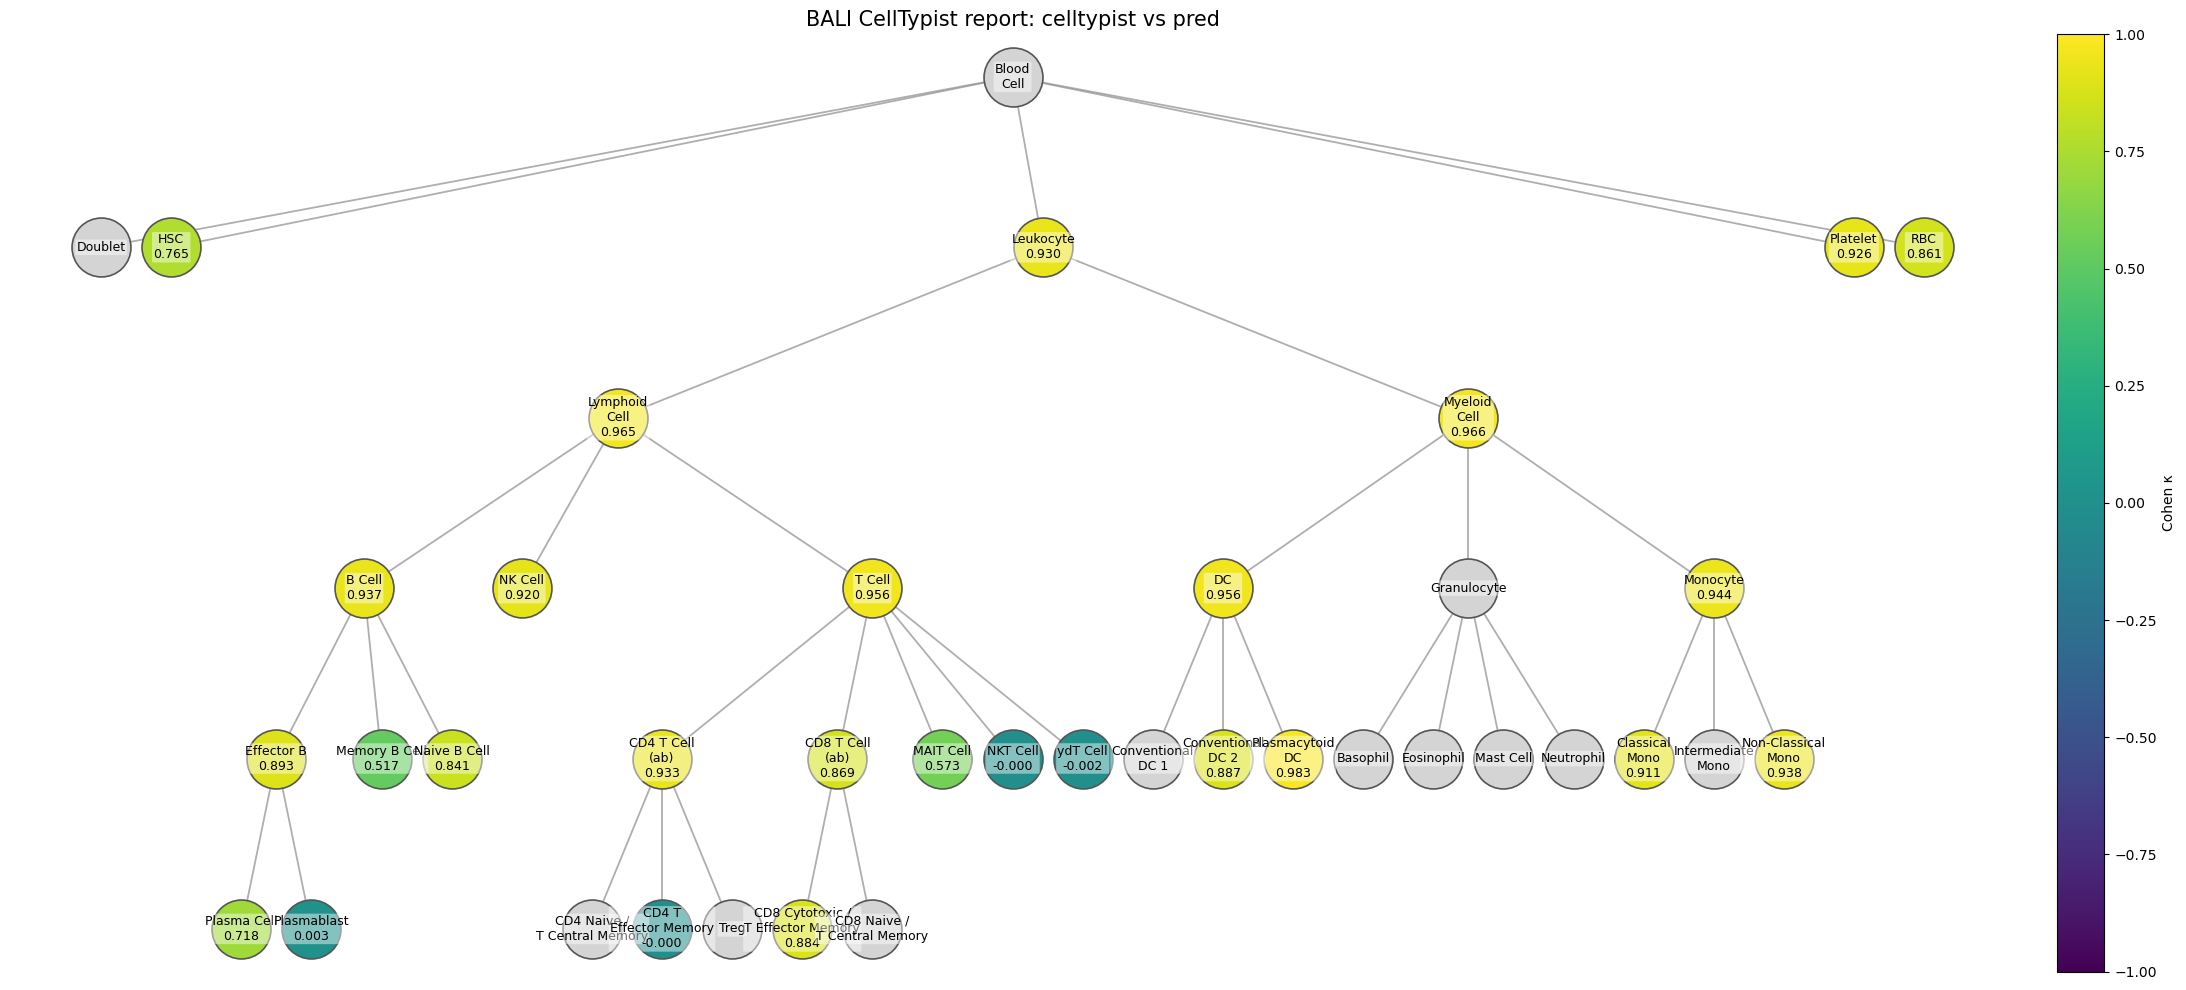


=== Summary: celltypist vs pred ===


,target_col,reference_col,n_valid_nodes,mean_kappa,median_kappa,min_kappa,max_kappa,n_low_kappa_nodes_lt_0.2,n_negative_kappa_nodes,major_message
0,celltypist,pred,27,0.743479,0.892769,-0.001612,0.982602,4,3,Overall agreement is strong across covered ont...



=== Node-level κ table head: celltypist vs pred ===


,Node,Level,target_col,reference_col,Kappa,target_positive_cells,reference_positive_cells,both_positive_cells,target_only_cells,reference_only_cells,either_positive_cells,jaccard_positive_set,target_to_reference_positive_ratio,Level0,Level1,Level2,Level3,Level4,Level5
0,Doublet,1,celltypist,pred,NaN,0,0,0,0,0,0,NaN,NaN,Blood Cell,Doublet,NaN,NaN,NaN,NaN
1,HSC,1,celltypist,pred,0.765331,407,638,401,6,237,644,0.622671,0.637931,Blood Cell,HSC,NaN,NaN,NaN,NaN
2,Leukocyte,1,celltypist,pred,0.929877,50104,49683,49588,516,95,50199,0.987828,1.008474,Blood Cell,Leukocyte,NaN,NaN,NaN,NaN
3,Platelet,1,celltypist,pred,0.926181,3863,4115,3716,147,399,4262,0.871891,0.938761,Blood Cell,Platelet,NaN,NaN,NaN,NaN
4,RBC,1,celltypist,pred,0.861285,211,216,184,27,32,243,0.757202,0.976852,Blood Cell,RBC,NaN,NaN,NaN,NaN
5,Lymphoid Cell,2,celltypist,pred,0.964648,30351,29963,29679,672,284,30635,0.968794,1.012949,Blood Cell,Leukocyte,Lymphoid Cell,NaN,NaN,NaN
6,Myeloid Cell,2,celltypist,pred,0.965942,19753,19720,19307,446,413,20166,0.957404,1.001673,Blood Cell,Leukocyte,Myeloid Cell,NaN,NaN,NaN
7,B Cell,3,celltypist,pred,0.937152,5321,5445,5078,243,367,5688,0.892757,0.977227,Blood Cell,Leukocyte,Lymphoid Cell,B Cell,NaN,NaN
8,NK Cell,3,celltypist,pred,0.920071,8282,8042,7607,675,435,8717,0.872663,1.029843,Blood Cell,Leukocyte,Lymphoid Cell,NK Cell,NaN,NaN
9,T Cell,3,celltypist,pred,0.955639,16748,16476,16099,649,377,17125,0.940088,1.016509,Blood Cell,Leukocyte,Lymphoid Cell,T Cell,NaN,NaN



=== Actionable feedback nodes: celltypist vs pred ===


,Node,Level,Kappa,target_positive_cells,reference_positive_cells,both_positive_cells,target_only_cells,reference_only_cells,jaccard_positive_set,target_to_reference_positive_ratio,direction,review_priority_score
0,CD4 T Effector Memory,5,-0.000494,2251,38,1,2250,37,0.000437,59.236842,target_overcalls_vs_reference,2.542671
1,Plasmablast,5,0.002868,678,2,1,677,1,0.001473,339.000000,target_overcalls_vs_reference,2.300887
2,ydT Cell,4,-0.001612,59,173,0,59,173,0.000000,0.341040,target_undercalls_vs_reference,1.985904
3,Memory B Cell,4,0.517192,919,365,335,584,30,0.353003,2.517808,target_overcalls_vs_reference,1.773476
4,Plasma Cell,5,0.718486,1272,2127,1235,37,892,0.570702,0.598025,target_undercalls_vs_reference,1.678363
5,Leukocyte,1,0.929877,50104,49683,49588,516,95,0.987828,1.008474,target_overcalls_vs_reference,1.518062
6,Naive B Cell,4,0.841272,2119,2668,2030,89,638,0.736308,0.794228,target_undercalls_vs_reference,1.501329
7,Classical Monocyte,4,0.911202,9275,9808,8842,433,966,0.863392,0.945657,target_undercalls_vs_reference,1.492570
8,CD8 T Cell (ab),4,0.868711,6127,5749,5243,884,506,0.790442,1.065751,target_overcalls_vs_reference,1.461918
9,Lymphoid Cell,2,0.964648,30351,29963,29679,672,284,0.968794,1.012949,target_overcalls_vs_reference,1.446385



=== Combined summary across references ===


,target_col,reference_col,n_valid_nodes,mean_kappa,median_kappa,min_kappa,max_kappa,n_low_kappa_nodes_lt_0.2,n_negative_kappa_nodes,major_message
0,celltypist,original,21,0.823468,0.878309,0.009074,0.967605,1,0,Overall agreement is strong across covered ont...
1,celltypist,pred,27,0.743479,0.892769,-0.001612,0.982602,4,3,Overall agreement is strong across covered ont...



=== Combined actionable feedback ===


,target_col,reference_col,Node,Level,Kappa,target_positive_cells,reference_positive_cells,both_positive_cells,target_only_cells,reference_only_cells,jaccard_positive_set,target_to_reference_positive_ratio,direction,review_priority_score
0,celltypist,original,Granulocyte,3,0.009074,37,2656,14,23,2642,0.005226,0.013931,target_undercalls_vs_reference,2.566244
1,celltypist,original,Plasmablast,5,0.460952,678,1812,586,92,1226,0.307773,0.374172,target_undercalls_vs_reference,1.971818
2,celltypist,original,Lymphoid Cell,2,0.898432,30351,27881,27731,2620,150,0.909183,1.088591,target_overcalls_vs_reference,1.789702
3,celltypist,original,NK Cell,3,0.858455,8282,6535,6500,1782,35,0.781532,1.267330,target_overcalls_vs_reference,1.712788
4,celltypist,original,Myeloid Cell,2,0.888648,19753,21226,19062,691,2164,0.869736,0.930604,target_undercalls_vs_reference,1.705465
5,celltypist,original,Leukocyte,1,0.872188,50104,49107,49018,1086,89,0.976590,1.020303,target_overcalls_vs_reference,1.704858
6,celltypist,original,CD4 T Cell (ab),4,0.858253,10188,9165,8547,1641,618,0.790949,1.111620,target_overcalls_vs_reference,1.645865
7,celltypist,original,Monocyte,3,0.899327,13933,12751,12326,1607,425,0.858476,1.092699,target_overcalls_vs_reference,1.640651
8,celltypist,original,Classical Monocyte,4,0.873903,9275,8684,8033,1242,651,0.809289,1.068056,target_overcalls_vs_reference,1.543774
9,celltypist,original,Non-Classical Monocyte,4,0.878309,4654,4067,3872,782,195,0.798515,1.144332,target_overcalls_vs_reference,1.502537


In [9]:
# Eui: CellTypist vs original and pred
celltypist_report_eui = run_individual_annotator_report(
    eui_onto_annotator_table,
    target_col="celltypist",
    reference_cols=["original", "pred"],
    include_root=False,
    min_pos_per_side=1,
    min_either_positive_cells_for_feedback=10,
    top_n_feedback=10,
    title_prefix="Eui CellTypist report",
)

# BALI: CellTypist vs original and pred
celltypist_report_bali = run_individual_annotator_report(
    bali_onto_annotator_table,
    target_col="celltypist",
    reference_cols=["original", "pred"],
    include_root=False,
    min_pos_per_side=1,
    min_either_positive_cells_for_feedback=10,
    top_n_feedback=10,
    title_prefix="BALI CellTypist report",
)